In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Tables & Final Stats

In [ ]:
df = pd.read_csv('/home/vmottaqi/rnaseq_synapse/metadata_merged.csv')

## Table 1 Overal Cohort description

In [9]:
import pandas as pd

# --- 1) Define your mapping dictionaries ---
tissue_map = {
    1: "ACC", 2: "CBE", 3: "DLFPC", 4: "FP", 5: "IFG",
    6: "PCC", 7: "PHG", 8: "STG", 9: "TCX"
}
diagnosis_map = {0: "Control", 1: "AD"}
sex_map = {0: "Male", 1: "Female"}

# --- 2) Convert numeric codes to strings in a copy of the DataFrame ---
df_formatted = df.copy()
df_formatted["tissue"] = df_formatted["tissue"].map(tissue_map)
df_formatted["diagnosis"] = df_formatted["diagnosis"].map(diagnosis_map)
df_formatted["sex"] = df_formatted["sex"].map(sex_map)

# --- 3) Group by study + tissue, then aggregate the desired columns ---
grouped = df_formatted.groupby(["study", "tissue"], dropna=False)
summary_df = grouped.agg(
    Total_Samples     = ("specimenID",   "count"),
    AD_Samples        = ("diagnosis",    lambda x: (x == "AD").sum()),
    Control_Samples   = ("diagnosis",    lambda x: (x == "Control").sum()),
    Male_Samples      = ("sex",          lambda x: (x == "Male").sum()),
    Female_Samples    = ("sex",          lambda x: (x == "Female").sum()),
    Total_Subjects = ("individualID", "nunique")
).reset_index()

# --- 4) Rename columns for final display ---
summary_df.rename(columns={
    "study": "Cohort/study",
    "tissue": "Tissue Name"
}, inplace=True)

# --- 5) Sort rows to get ROSMAP, MSBB, then MAYO, and by Tissue name ---
study_order = ["ROSMAP", "MSBB", "MAYO"]
summary_df["Cohort/study"] = pd.Categorical(
    summary_df["Cohort/study"],
    categories=study_order,
    ordered=True
)
summary_df.sort_values(["Cohort/study", "Tissue Name"], inplace=True)

# --- 6) Add a final "TOTAL" row that sums across all rows ---
sum_row = {
    "Cohort/study":   "TOTAL",
    "Tissue Name":    "ALL TISSUES",
    "Total_Samples":     summary_df["Total_Samples"].sum(),
    "AD_Samples":        summary_df["AD_Samples"].sum(),
    "Control_Samples":   summary_df["Control_Samples"].sum(),
    "Male_Samples":      summary_df["Male_Samples"].sum(),
    "Female_Samples":    summary_df["Female_Samples"].sum(),
    "Total_Subjects": summary_df["Total_Subjects"].sum()
}
summary_df = pd.concat([summary_df, pd.DataFrame([sum_row])], ignore_index=True)

# --- 7) Export the summary table to CSV ---
summary_df.to_csv("/home/vmottaqi/rnaseq_synapse/Table1_overall_cohort_description.csv", index=False)

summary_df


,Cohort/study,Tissue Name,Total_Samples,AD_Samples,Control_Samples,Male_Samples,Female_Samples,Total_Subjects
0,ROSMAP,ACC,265,171,94,90,175,265
1,ROSMAP,DLFPC,436,293,143,143,293,429
2,ROSMAP,PCC,250,151,99,97,153,249
3,MSBB,FP,215,146,69,83,132,197
4,MSBB,IFG,201,132,69,86,115,181
5,MSBB,PHG,226,155,71,84,142,168
6,MSBB,STG,220,156,64,93,127,181
7,MAYO,CBE,144,79,65,69,75,144
8,MAYO,TCX,148,80,68,66,82,148
9,TOTAL,ALL TISSUES,2105,1363,742,811,1294,1962


In [3]:
import pandas as pd

# Assuming your DataFrame is loaded in the variable `df`
# For example: df = pd.read_csv('your_dataset.csv')

# Remove duplicate entries so that each individualID appears only once
unique_individuals = df.drop_duplicates(subset='individualID')

# Total number of unique individuals
total_unique = unique_individuals.shape[0]

# Count by sex: assuming 0 represents male and 1 represents female
male_count = unique_individuals[unique_individuals['sex'] == 0].shape[0]
female_count = unique_individuals[unique_individuals['sex'] == 1].shape[0]

print("Total unique individuals:", total_unique)
print("Number of males:", male_count)
print("Number of females:", female_count)


Total unique individuals: 835
Number of males: 307
Number of females: 528


In [4]:
# Count samples per tissue
tissue_counts = df['tissue'].value_counts().sort_index()

# Given mapping: tissue names to numeric codes
tissue_mapping = {'ACC': 1, 'CBE': 2, 'DLFPC': 3, 'FP': 4, 'IFG': 5, 'PCC': 6, 'PHG': 7, 'STG': 8, 'TCX': 9}

# Create an inverse mapping: numeric codes to tissue names
inverse_tissue_mapping = {code: name for name, code in tissue_mapping.items()}

# Map the numeric tissue codes to their corresponding tissue names in the counts Series
tissue_counts.index = tissue_counts.index.map(lambda code: inverse_tissue_mapping.get(code, code))

print("Number of samples per tissue:")
print(tissue_counts)


Number of samples per tissue:
tissue
ACC      265
CBE      144
DLFPC    436
FP       215
IFG      201
PCC      250
PHG      226
STG      220
TCX      148
Name: count, dtype: int64


## Table S1 Subtissue Summaries and Stats

In [20]:
import pickle

with open ('/home/vmottaqi/rnaseq_synapse/novel_hub_genes_by_cluster.pkl', 'rb') as f:
    bottlenecks_dict = pickle.load(f)

bottlenecks_dict

{'1_1': [('LOC107986669', 1.0, 'betweenness'),
  ('CTSK', 2.0, 'betweenness'),
  ('MEI1', 1.0, 'closeness'),
  ('LOC105371735', 2.0, 'closeness'),
  ('TNFSF13B', 3.0, 'closeness'),
  ('ZNF837', 4.0, 'closeness'),
  ('ZCCHC24', 1.0, 'pagerank'),
  ('SMPX', 2.0, 'pagerank'),
  ('COL19A1', 3.0, 'pagerank'),
  ('KEL', 4.0, 'pagerank'),
  ('TNFSF13B', 5.0, 'pagerank')],
 '1_2': [('TGFA', 1.0, 'betweenness'),
  ('FRMPD4', 2.0, 'betweenness'),
  ('WWTR1', 3.0, 'betweenness'),
  ('WWTR1', 1.0, 'closeness')],
 '1_3': [('PLPP3', 1.0, 'degree'),
  ('ADAMTS1', 1.0, 'betweenness'),
  ('DCDC1', 2.0, 'betweenness'),
  ('CFAP300', 3.0, 'betweenness'),
  ('LENG9', 4.0, 'betweenness'),
  ('CYBA', 5.0, 'betweenness'),
  ('ZYX', 1.0, 'closeness'),
  ('FJX1', 2.0, 'closeness'),
  ('PDE1B', 1.0, 'eigenvector'),
  ('KCNV1', 2.0, 'eigenvector'),
  ('DLX6', 3.0, 'eigenvector'),
  ('XK', 4.0, 'eigenvector'),
  ('DCAF12L2', 5.0, 'eigenvector'),
  ('PLPP3', 1.0, 'pagerank'),
  ('ANO6', 2.0, 'pagerank'),
  ('MIR36

In [49]:
df = pd.read_csv('/home/vmottaqi/rnaseq_synapse/summary_shap_gwas_intermediates.csv', index_col=0)


# --- FUNCTION TO EXTRACT UNIQUE GENE NAMES ---
def get_unique_bottlenecks(cluster_label):
    """
    Returns a tuple: (count, stringified_list_of_unique_genes)
    If cluster_label not in dictionary, returns (0, '[]').
    """
    if cluster_label not in bottlenecks_dict:
        return 0, "[]"
    # Get gene names (the first element of each tuple)
    gene_names = [t[0] for t in bottlenecks_dict[cluster_label]]
    # Remove duplicates by converting to a set, then back to a list
    unique_gene_names = sorted(set(gene_names))
    # Convert to string, matching the bracket style in your existing DataFrame
    return len(unique_gene_names), str(unique_gene_names)

# --- ADD TWO NEW COLUMNS ---
df["Hub Genes Count"] = 0
df["Hub Genes"] = ""

for i, row in df.iterrows():
    cluster = row["Cluster"]
    n_unique, genes_str = get_unique_bottlenecks(cluster)
    df.loc[i, "Hub Genes Count"] = n_unique
    df.loc[i, "Hub Genes"] = genes_str

# OPTIONAL: Convert "Hub Genes Count" to int if needed
df["Hub Genes Count"] = df["Hub Genes Count"].astype(int)



# Tissue map
tissue_map = {
    1: "ACC",
    2: "CBE",
    3: "DLFPC",
    4: "FP",
    5: "IFG",
    6: "PCC",
    7: "PHG",
    8: "STG",
    9: "TCX"
}

def convert_cluster_label(label):
    """Convert e.g. '1_1' -> 'ACC_1', '4_4' -> 'FP_4'."""
    tissue_code_str, sub_cluster_str = label.split("_")
    tissue_code = int(tissue_code_str)     # e.g. '1' -> 1
    tissue_name = tissue_map[tissue_code]  # e.g. 1 -> "ACC"
    return f"{tissue_name}_{sub_cluster_str}"

# Create a new column or replace the original
df["Cluster"] = df["Cluster"].apply(convert_cluster_label)


df.head()

,Cluster,Study,Samples in Cluster,Unique Individuals,Common SHAP Genes Count,Common SHAP Genes,Individuals_gwas,GWAS snps count,GWAS snps,GWAS Genes,GWAS Genes Count,Total Unique Intermediates,Unique Intermediates List,Hub Genes Count,Hub Genes
0,ACC_1,ROSMAP,4,4,46,"['SLC7A2', 'NWD1', 'LPL', 'SLC5A3', 'EMP3', 'L...",2,120,"['rs41281314', 'rs7917781', 'rs55717455', 'rs1...","['CR1', 'FERMT2', 'ZNF423', 'HLA-DQA1', 'KCNQ5...",29,2583.0,"['GALNT7', 'GBP1', 'SLC9A2', 'RPS2', 'RGS8', '...",10,"['COL19A1', 'CTSK', 'KEL', 'LOC105371735', 'LO..."
1,ACC_2,ROSMAP,18,18,21,"['SLC5A3', 'TRIP10', 'LINC01736', 'GAREM2', 'B...",13,114,"['rs7903757', 'rs12572738', 'rs10999979', 'rs4...","['PICALM', 'CR1', 'MAP1B', 'BIN1', 'TMEM170B',...",31,611.0,"['SLC9A2', 'TRIM5', 'ANO6', 'DACH1', 'HPCA', '...",3,"['FRMPD4', 'TGFA', 'WWTR1']"
2,ACC_3,ROSMAP,11,11,18,"['KANK2', 'A2ML1', 'SVOP', 'ITPKB', 'CSRP1', '...",8,128,"['rs4747187', 'rs10902249', 'rs693458', 'rs545...","['PICALM', 'SHARPIN', 'MAP1B', 'BIN1', 'FERMT2...",36,631.0,"['APP', 'GALNT12', 'ANTKMT', 'NDRG1', 'RGS8', ...",15,"['ADAMTS1', 'ANO6', 'CFAP300', 'CYBA', 'DCAF12..."
3,ACC_4,ROSMAP,21,21,12,"['KANK2', 'DUSP1', 'A2ML1', 'PIRT', 'SLC5A3', ...",17,93,"['rs10999882', 'rs74147331', 'rs74147345', 'rs...","['CYP11A1', 'ZNF423', 'HLA-DQA1', 'SUOX', 'KCN...",28,227.0,"['NUDT4', 'GALNT12', 'SYP', 'SELENOP', 'WDR49'...",7,"['AKAP5', 'GNG12', 'LIFR', 'PDLIM5', 'SLC4A10'..."
4,CBE_1,MAYO,7,7,28,"['SLC7A2', 'NWD1', 'AHNAK', 'SLC5A3', 'APLNR',...",7,18,"['rs7667050', 'rs7268', 'rs2074613', 'rs340225...","['MLH3', 'ZNF423', 'PPARGC1A', 'HBEGF', 'RORA'...",9,489.0,"['WFIKKN2', 'SAMD11', 'SIGLEC14', 'ST8SIA6', '...",12,"['CCDC150', 'CGAS', 'FLI1', 'HBEGF', 'LIX1', '..."


In [50]:
df.drop(columns=['Individuals_gwas'], inplace=True)

# 1) Reorder columns: specify the new order as a list
new_order = ['Cluster', 'Study', 'Samples in Cluster', 'Unique Individuals', 'Common SHAP Genes Count', 
             'GWAS snps count', 'GWAS Genes Count', 'Total Unique Intermediates','Hub Genes Count',
             'Common SHAP Genes', 'GWAS snps', 'GWAS Genes', 'Unique Intermediates List', 'Hub Genes']  # any order you like
df = df[new_order]

df.rename(columns={'Cluster': 'Subtissue','Study': 'Cohort/study','Samples in Cluster': 'Total_Samples','Unique Individuals': 'Total_Subjects',
                   'Common SHAP Genes Count': 'Biomarker_Genes_Count','GWAS snps count': 'Genetic_Drivers_SNPs_Count',
                   'GWAS Genes Count': 'Genetic_Driver_Genes_Count',
                   'Total Unique Intermediates': 'Intermediate_Genes_Count','Hub Genes Count': 'Bottleneck_Genes_Count',
                   'Common SHAP Genes': 'Biomarker_Genes','GWAS snps': 'Genetic_Drivers_SNPs',
                   'GWAS Genes': 'Genetic_Driver_Genes',
                   'Unique Intermediates List': 'Intermediate_Genes','Hub Genes': 'Bottleneck_Genes'}, inplace=True)

# Replace NaN or 0 with "[]" in the last two columns
for col in df.columns[-2:]:  # slice the last 2 columns
    df[col] = df[col].apply(lambda x: "[]" if (pd.isnull(x) or x == 0) else x)


df.head()

,Subtissue,Cohort/study,Total_Samples,Total_Subjects,Biomarker_Genes_Count,Genetic_Drivers_SNPs_Count,Genetic_Driver_Genes_Count,Intermediate_Genes_Count,Bottleneck_Genes_Count,Biomarker_Genes,Genetic_Drivers_SNPs,Genetic_Driver_Genes,Intermediate_Genes,Bottleneck_Genes
0,ACC_1,ROSMAP,4,4,46,120,29,2583.0,10,"['SLC7A2', 'NWD1', 'LPL', 'SLC5A3', 'EMP3', 'L...","['rs41281314', 'rs7917781', 'rs55717455', 'rs1...","['CR1', 'FERMT2', 'ZNF423', 'HLA-DQA1', 'KCNQ5...","['GALNT7', 'GBP1', 'SLC9A2', 'RPS2', 'RGS8', '...","['COL19A1', 'CTSK', 'KEL', 'LOC105371735', 'LO..."
1,ACC_2,ROSMAP,18,18,21,114,31,611.0,3,"['SLC5A3', 'TRIP10', 'LINC01736', 'GAREM2', 'B...","['rs7903757', 'rs12572738', 'rs10999979', 'rs4...","['PICALM', 'CR1', 'MAP1B', 'BIN1', 'TMEM170B',...","['SLC9A2', 'TRIM5', 'ANO6', 'DACH1', 'HPCA', '...","['FRMPD4', 'TGFA', 'WWTR1']"
2,ACC_3,ROSMAP,11,11,18,128,36,631.0,15,"['KANK2', 'A2ML1', 'SVOP', 'ITPKB', 'CSRP1', '...","['rs4747187', 'rs10902249', 'rs693458', 'rs545...","['PICALM', 'SHARPIN', 'MAP1B', 'BIN1', 'FERMT2...","['APP', 'GALNT12', 'ANTKMT', 'NDRG1', 'RGS8', ...","['ADAMTS1', 'ANO6', 'CFAP300', 'CYBA', 'DCAF12..."
3,ACC_4,ROSMAP,21,21,12,93,28,227.0,7,"['KANK2', 'DUSP1', 'A2ML1', 'PIRT', 'SLC5A3', ...","['rs10999882', 'rs74147331', 'rs74147345', 'rs...","['CYP11A1', 'ZNF423', 'HLA-DQA1', 'SUOX', 'KCN...","['NUDT4', 'GALNT12', 'SYP', 'SELENOP', 'WDR49'...","['AKAP5', 'GNG12', 'LIFR', 'PDLIM5', 'SLC4A10'..."
4,CBE_1,MAYO,7,7,28,18,9,489.0,12,"['SLC7A2', 'NWD1', 'AHNAK', 'SLC5A3', 'APLNR',...","['rs7667050', 'rs7268', 'rs2074613', 'rs340225...","['MLH3', 'ZNF423', 'PPARGC1A', 'HBEGF', 'RORA'...","['WFIKKN2', 'SAMD11', 'SIGLEC14', 'ST8SIA6', '...","['CCDC150', 'CGAS', 'FLI1', 'HBEGF', 'LIX1', '..."


In [51]:
import pandas as pd
import ast


numeric_cols = [
    "Total_Samples",
    "Total_Subjects",
    "Biomarker_Genes_Count",
    "Genetic_Drivers_SNPs_Count",
    "Genetic_Driver_Genes_Count",
    "Intermediate_Genes_Count",
    "Bottleneck_Genes_Count"
]

list_cols = [
    "Biomarker_Genes",
    "Genetic_Drivers_SNPs",
    "Genetic_Driver_Genes",
    "Intermediate_Genes",
    "Bottleneck_Genes"
]

# A) Separate which numeric columns to *sum*, and which to map to a list column
#    i.e. the user wants *Counts* = length of the merged sets.
#    For clarity, define them explicitly:
sum_cols = ["Total_Samples", "Total_Subjects"]

# These pairs map a "count column" to its associated "list column"
unique_count_map = {
    "Biomarker_Genes_Count":       "Biomarker_Genes",
    "Genetic_Drivers_SNPs_Count":  "Genetic_Drivers_SNPs",
    "Genetic_Driver_Genes_Count":  "Genetic_Driver_Genes",
    "Intermediate_Genes_Count":    "Intermediate_Genes",
    "Bottleneck_Genes_Count":      "Bottleneck_Genes"
}

# B) Define a helper function to merge bracketed-list columns into one set
def merge_lists(series):
    """
    For a column that stores bracketed strings like "['geneA','geneB']",
    parse each row, accumulate unique items in a set, then return a
    bracketed list string of the sorted unique items.
    """
    master_set = set()
    for val in series:
        if isinstance(val, str):
            try:
                parsed_list = ast.literal_eval(val)  # parse bracketed string
                master_set.update(parsed_list)
            except Exception:
                # if parse fails, skip
                pass
        # if not a string, skip or treat as empty
    return str(sorted(master_set))

# 1) For the "sum_cols", we do normal summation
sums_dict = {}
for col in sum_cols:
    sums_dict[col] = df[col].sum()

# 2) Merge each list column into a single set, store the bracketed string,
#    then compute how many unique items that set has.
lists_dict = {}
counts_for_lists = {}

for list_col in list_cols:
    merged_str = merge_lists(df[list_col])
    lists_dict[list_col] = merged_str
    
    # Identify if there's a corresponding *Count column
    for count_col, col_match in unique_count_map.items():
        if col_match == list_col:
            # parse the merged_str to count unique items
            try:
                items = ast.literal_eval(merged_str)
                counts_for_lists[count_col] = len(items)
            except Exception:
                counts_for_lists[count_col] = 0

# 3) Construct the final row dict
#    - Subtissue, Cohort/study columns set to "TOTAL"/"ALL"
#    - Summation columns
#    - Unique-count columns
#    - Merged-list columns
total_row = {
    "Subtissue": "TOTAL",
    "Cohort/study": "ALL"
}

# Add the sums for sum_cols
total_row.update(sums_dict)
# Add the unique counts for the list columns
total_row.update(counts_for_lists)
# Add the merged bracketed-list strings
total_row.update(lists_dict)

# 4) Append the TOTAL row to df
df_final = pd.concat([df, pd.DataFrame([total_row])], ignore_index=True)

df_final


,Subtissue,Cohort/study,Total_Samples,Total_Subjects,Biomarker_Genes_Count,Genetic_Drivers_SNPs_Count,Genetic_Driver_Genes_Count,Intermediate_Genes_Count,Bottleneck_Genes_Count,Biomarker_Genes,Genetic_Drivers_SNPs,Genetic_Driver_Genes,Intermediate_Genes,Bottleneck_Genes
0,ACC_1,ROSMAP,4,4,46,120,29,2583.0,10,"['SLC7A2', 'NWD1', 'LPL', 'SLC5A3', 'EMP3', 'L...","['rs41281314', 'rs7917781', 'rs55717455', 'rs1...","['CR1', 'FERMT2', 'ZNF423', 'HLA-DQA1', 'KCNQ5...","['GALNT7', 'GBP1', 'SLC9A2', 'RPS2', 'RGS8', '...","['COL19A1', 'CTSK', 'KEL', 'LOC105371735', 'LO..."
1,ACC_2,ROSMAP,18,18,21,114,31,611.0,3,"['SLC5A3', 'TRIP10', 'LINC01736', 'GAREM2', 'B...","['rs7903757', 'rs12572738', 'rs10999979', 'rs4...","['PICALM', 'CR1', 'MAP1B', 'BIN1', 'TMEM170B',...","['SLC9A2', 'TRIM5', 'ANO6', 'DACH1', 'HPCA', '...","['FRMPD4', 'TGFA', 'WWTR1']"
2,ACC_3,ROSMAP,11,11,18,128,36,631.0,15,"['KANK2', 'A2ML1', 'SVOP', 'ITPKB', 'CSRP1', '...","['rs4747187', 'rs10902249', 'rs693458', 'rs545...","['PICALM', 'SHARPIN', 'MAP1B', 'BIN1', 'FERMT2...","['APP', 'GALNT12', 'ANTKMT', 'NDRG1', 'RGS8', ...","['ADAMTS1', 'ANO6', 'CFAP300', 'CYBA', 'DCAF12..."
3,ACC_4,ROSMAP,21,21,12,93,28,227.0,7,"['KANK2', 'DUSP1', 'A2ML1', 'PIRT', 'SLC5A3', ...","['rs10999882', 'rs74147331', 'rs74147345', 'rs...","['CYP11A1', 'ZNF423', 'HLA-DQA1', 'SUOX', 'KCN...","['NUDT4', 'GALNT12', 'SYP', 'SELENOP', 'WDR49'...","['AKAP5', 'GNG12', 'LIFR', 'PDLIM5', 'SLC4A10'..."
4,CBE_1,MAYO,7,7,28,18,9,489.0,12,"['SLC7A2', 'NWD1', 'AHNAK', 'SLC5A3', 'APLNR',...","['rs7667050', 'rs7268', 'rs2074613', 'rs340225...","['MLH3', 'ZNF423', 'PPARGC1A', 'HBEGF', 'RORA'...","['WFIKKN2', 'SAMD11', 'SIGLEC14', 'ST8SIA6', '...","['CCDC150', 'CGAS', 'FLI1', 'HBEGF', 'LIX1', '..."
5,CBE_2,MAYO,4,4,56,45,16,1640.0,9,"['SLC7A2', 'GPRASP2', 'AHNAK', 'THCAT155', 'NW...","['rs974711', 'rs4704187', 'rs1564926', 'rs6915...","['CDH23', 'FUS', 'ZNF423', 'WIPI2', 'AP4E1', '...","['APP', 'MICB', 'MT1X', 'FGF5', 'IL1RAPL2', 'E...","['ADGRL1-AS1', 'ATOH8', 'BEND6', 'CNTNAP2', 'C..."
6,CBE_3,MAYO,5,5,41,12,6,460.0,11,"['GPRASP2', 'AHNAK', 'SCG2', 'SLC5A3', 'EMP3',...","['rs7919533', 'rs10902249', 'rs340019', 'rs340...","['CDH23', 'AP2A2', 'RORA', 'CD33', 'PLCG2', 'I...","['SAMD11', 'SIGLEC14', 'ARSL', 'PTPRT', 'LINC0...","['ABTB3', 'ADAM12', 'CEND1', 'KCNQ5', 'LOC1053..."
7,CBE_4,MAYO,2,2,80,20,8,NaN,0,"['ANGPT2', 'PTPRU', 'CHST6', 'PADI2', 'ADPGK-A...","['rs541464', 'rs7562227', 'rs6419133', 'rs3807...","['HP1BP3', 'ACE', 'BIN1', 'UNC5C', 'CNTNAP2', ...",[],[]
8,DLFPC_1,ROSMAP,19,19,26,84,31,820.0,11,"['SDSL', 'THCAT155', 'SCG2', 'LPL', 'PTPRU', '...","['rs1227078', 'rs1227075', 'rs1227069', 'rs412...","['FNBP4', 'TACR3', 'CR1', 'MAP1B', 'PILRA', 'F...","['APP', 'SMPD4P1', 'PTPRT', 'RPS2', 'HLA-DMB',...","['DLC1', 'GPR37', 'LNX1', 'MDH1', 'NEFM', 'OLF..."
9,DLFPC_2,ROSMAP,19,19,26,163,39,793.0,5,"['SLC7A2', 'THCAT155', 'SCG2', 'PTPRU', 'LPL',...","['rs1125168', 'rs12266801', 'rs10999947', 'rs1...","['FNBP4', 'TACR3', 'CYP11A1', 'CCDC6', 'BIN1',...","['APP', 'GALNT12', 'TBC1D16', 'ANTKMT', 'RPS2'...","['ELOVL4', 'FGF12', 'NMNAT2', 'PNMA5', 'RAB3A']"


In [52]:
df_final.to_csv('/home/vmottaqi/rnaseq_synapse/S1_subtissues_stats.csv', index=False)

# Visualization Plots

## 1. PCA, UMAP and tSNE

In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from umap import UMAP
import seaborn as sns

def plot(data, metadata, plot_type='umap', name=None, title=None, 
         Palette='colorblind', S=30, Alpha=0.8, Hue='tissue'):
    # Tissue dictionary and its reverse for mapping
    Tissue = { 'DLFPC':3, 'ACC':1, 'CBE':2, 'FP':4, 'IFG':5, 'PCC':6, 'PHG':7, 'STG':8,'TCX':9}
    Tissue_reversed = {v: k for k, v in Tissue.items()}

    # Replace numeric tissue codes with names
    metadata[Hue] = metadata[Hue].map(Tissue_reversed)

    # Prepare data
    features = data.values
    labels = metadata[Hue].astype('category')

    # Ensure order of tissues as per the Tissue dictionary
    order = list(Tissue.keys())  # List of tissue names in the specified order

    # Initialize and fit the reducer
    if plot_type == 'umap':
        reducer = UMAP(random_state=42)
        embedding = reducer.fit_transform(features)
        plot_title = 'UMAP'
    elif plot_type == 'tsne':
        reducer = TSNE(n_components=2, random_state=42)
        embedding = reducer.fit_transform(features)
        plot_title = 't-SNE'
    elif plot_type == 'pca':
        reducer = PCA(n_components=2)
        embedding = reducer.fit_transform(features)
        plot_title = 'PCA'
    else:
        raise ValueError(f"Unsupported plot_type '{plot_type}'. Choose from 'umap', 'tsne', or 'pca'.")

    # Plot
    plt.figure(figsize=(6, 5))
    scatter = sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=metadata[Hue], 
                              palette=Palette, legend='full', s=S, edgecolor='white', alpha=Alpha, hue_order=order)
    plt.legend(title=Hue.capitalize(), bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlabel(f'{plot_title}-1')
    plt.ylabel(f'{plot_title}-2')
    
    # Optional custom title
    if title:
        plt.title(title)
    
    # Save the plot if a name is provided
    if name:
        plt.savefig(f"./figures/{name}_{plot_type.lower()}_Dec26.png", dpi=1200, bbox_inches='tight')
    plt.show()

# Example usage:
# plot(data, metadata, plot_type='umap', name='ExamplePlot', title='UMAP Visualization')



In [91]:
df = pd.read_csv("rnaseq_meta_with_clusters.csv", index_col=0)

# Create df2 with columns until the 16th (inclusive, assuming 0-based indexing)
data = df.iloc[:, 19:]
# Create df1 with columns from the 16th onward
metadata = df.iloc[:, :19]

In [89]:
data = pd.read_csv("rnaseq_merged_5k.csv", index_col=0)
metadata = pd.read_csv("metadata_merged.csv", index_col=0)

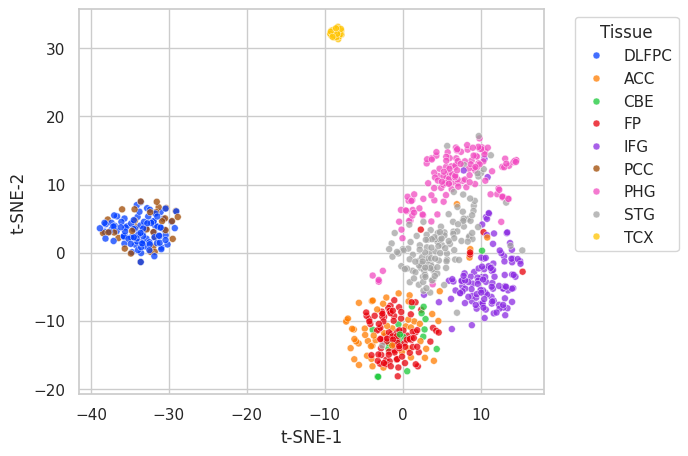

In [92]:
plot(data, metadata, plot_type='tsne', Palette='bright', S=25, Alpha=0.75, name = "filt_patients_tissue")

PCA

In [ ]:
df = pd.read_csv('rnaseq_meta.csv', index_col=0)
df

,individualID,diagnosis,tissue,race,spanish,apoe4_allele,sex,batch,pmi,RIN,...,GJB6,CCDC183-AS1,KLF15,AGTRAP,EZR,C2orf15,LMO2,GAREM2,ZBTB16,SDSL
specimenID,,,,,,,,,,,,,,,,,,,,,
hB_RNA_4411,AMPAD_MSSM_0000077445,1,5,1.0,2.0,1,1,14,6.583333,3.9,...,-0.591848,0.142189,0.371563,0.059603,0.059281,0.274474,0.357874,0.156186,-0.074227,-0.277443
hB_RNA_12484,AMPAD_MSSM_0000034015,1,4,1.0,2.0,1,1,20,5.250000,4.2,...,0.214412,-0.187430,-0.156292,-0.190344,0.008100,0.273406,0.056397,-0.258564,-0.294504,-0.404002
hB_RNA_16295,AMPAD_MSSM_0000083367,1,5,1.0,2.0,0,0,5,15.250000,10.0,...,0.101255,-0.134110,0.138174,0.277939,0.206213,-0.942221,0.589214,-0.088010,-0.189206,-0.178790
BM_10_674,AMPAD_MSSM_0000098979,1,4,1.0,2.0,0,1,21,19.333333,5.0,...,0.307214,0.853469,0.242229,0.054418,0.095695,-0.317063,-0.177276,0.088239,0.198327,0.010501
hB_RNA_16665,AMPAD_MSSM_0000034450,1,5,1.0,2.0,0,1,6,3.583333,9.9,...,-0.173683,0.519355,0.347839,0.285156,0.130551,-0.479695,0.286889,0.250938,-0.097065,-0.094118
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hB_RNA_7775,AMPAD_MSSM_0000077061,1,8,9.0,1.0,0,1,7,5.500000,9.9,...,-0.486417,0.537512,0.348259,0.237720,-0.034479,-0.072609,0.170131,0.223767,0.276840,0.480200
BM_36_545,AMPAD_MSSM_0000076188,1,7,1.0,2.0,0,0,18,5.733333,6.5,...,-0.573104,-0.220458,0.630038,0.585316,-0.106984,0.244389,0.238596,0.207993,-0.222866,-0.566743
Sample_R6636386-AC,R6636386,1,1,1.0,2.0,0,0,13,19.500000,6.0,...,-0.091409,-0.127889,0.173018,-0.006432,0.103108,-0.426582,0.099830,0.468877,-0.164213,0.234050


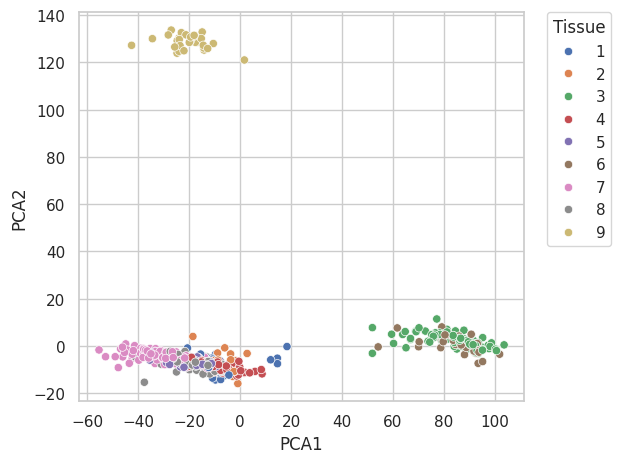

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('rnaseq_meta_with_clusters.csv', index_col=0)
# df = df[df['tissue'] == 9]

# Separate the features and the target 'tissue' column
features = df.iloc[:, 19:]  # Features start from column 7 (0-based index)
target = df['tissue']

# Run PCA on the features
pca = PCA(n_components=2)  # Adjusted to 2 components for visualization
X_pca = pca.fit_transform(features)

# Encode the 'tissue' labels
le = LabelEncoder()
y_lan = le.fit_transform(target)

# Create a DataFrame for PCA results
pca_df = pd.DataFrame({
    "PCA1": X_pca[:, 0],
    "PCA2": X_pca[:, 1],
    "Tissue": target,
    "label": y_lan
})

# Plot the PCA results
sns.set(style="whitegrid", palette="muted")
ax = sns.scatterplot(x="PCA1", y="PCA2", hue="Tissue", data=pca_df, palette="deep")
plt.legend(title="Tissue", bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.savefig('./figures/pca_original_tissues.png', dpi=900)
plt.show()


In [ ]:
data = pd.read_csv("rnaseq_merged_5k.csv", index_col=0)
metadata = pd.read_csv("metadata_merged.csv", index_col=0)

/home/vmottaqi/.conda/envs/visual/lib/python3.10/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


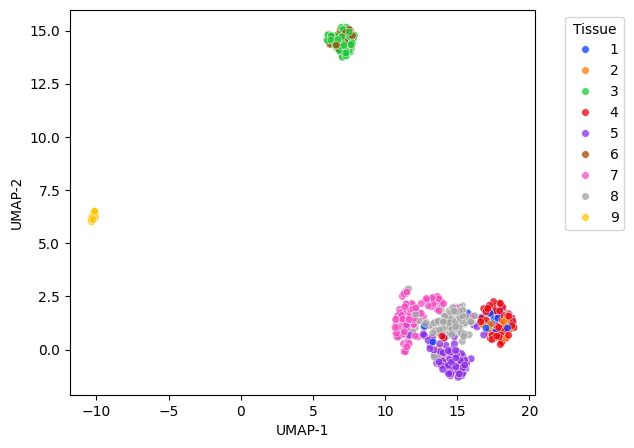

In [ ]:
plot(data, metadata, plot_type='umap', Palette='bright', S=30, Alpha=0.75) #, name = "allsamples_tissue" "filt_patients_tissue"

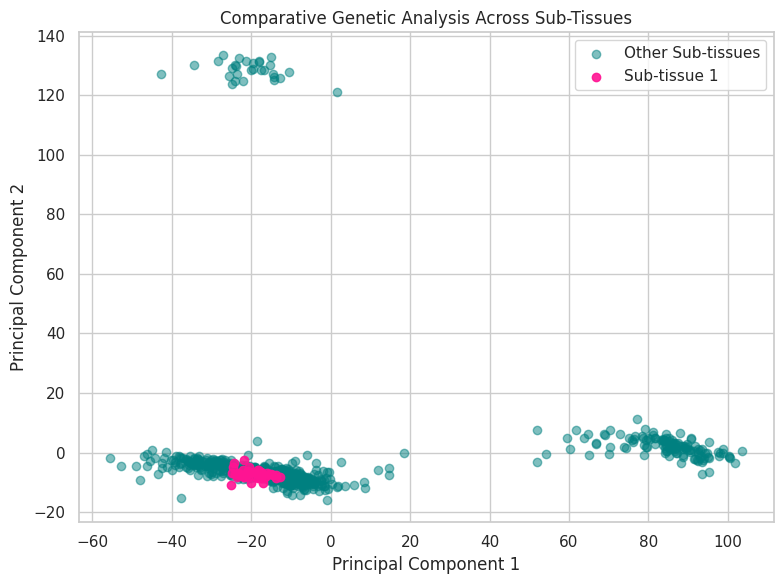

In [ ]:
import pandas as pd
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('rnaseq_meta_with_clusters.csv', index_col=0)

# Separate the features and the labels
features = df.iloc[:, 19:]  # Assuming gene expression starts from the 20th column
clusters = df['clusters']  # Assuming 'clusters' is the column with cluster information

# Define the specific cluster to highlight
specific_cluster = '8_3'  # Specify your cluster of interest

# Run PCA on the features
pca = PCA(n_components=2)  # Adjusted to 2 components for visualization
principal_components = pca.fit_transform(features)

# Plot
plt.figure(figsize=(8, 6))
# Plot all points that are not the specific cluster first, with slight transparency
mask = clusters != specific_cluster
plt.scatter(principal_components[mask, 0], principal_components[mask, 1], c='Teal', label='Other Sub-tissues', alpha=0.5)  # Alpha for transparency

# Then plot the specific cluster on top with no transparency
mask = clusters == specific_cluster
plt.scatter(principal_components[mask, 0], principal_components[mask, 1], c='deeppink', label='Sub-tissue 1', alpha=0.9)  # Alpha at 1 for full color

plt.title('Comparative Genetic Analysis Across Sub-Tissues')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('./figures/5k_pca_subtissue_vs_others.png', dpi=1000)
plt.show()


## 2. Plots of shap values for patient-specific biomarkers

### 1. Density plot

Frist get the list of genes of interest (biomarkers) and then plot

In [1]:
import pickle
with open('shap_5k_filt.pkl', 'rb') as f:
    shap_values = pickle.load(f)
shap_values

{'hB_RNA_4411': {'LINC00507': 0.0002853742039155358,
  'LTF': 0.0007401724256378097,
  'RGS4': 0.0005818160717220573,
  'ADAMTS2': 0.001913665065667479,
  'NCALD': 0.0005668815320401442,
  'PDYN': 0.00027065823569398013,
  'TMEM132E-DT': 0.00026339288700847317,
  'RASL12': 0.00028909190454119883,
  'PCP4L1': 0.0007466180463364811,
  'PPEF1': 0.0019267930102957972,
  'CD44': 0.000559878113790546,
  'PDE10A': 0.0005294122347517607,
  'CRH': 0.0009844417544397305,
  'APLNR': 0.0005823942894469631,
  'IL1B': 0.0002680709635158561,
  'LPL': 0.000962508323747331,
  'SCIN': 0.001198132876742495,
  'C4B': 0.0005082084174493945,
  'EGR2': 0.0002919329379273221,
  'VGF': 0.007799271057804959,
  'PIRT': 0.0024877966804218066,
  'C11orf87': 0.0007126768468804063,
  'CACNG8': 0.0004005308665662679,
  'COL25A1': 0.0002788415214441352,
  'ACY3': 0.000290017841064291,
  'MFAP4': 0.0002632307644024798,
  'CNTNAP5-DT': 0.00040613379598424833,
  'C4A': 0.00034585614960805133,
  'EPCIP': 0.000350340800000

In [33]:
data = shap_values

In [34]:
# Initialize a dictionary to keep track of total scores and counts for each gene
gene_scores = {}

# Loop through each sample and each gene in the sample
for sample, genes in data.items():
    for gene, score in genes.items():
        if gene not in gene_scores:
            gene_scores[gene] = {'total_score': 0, 'count': 0}
        gene_scores[gene]['total_score'] += score
        gene_scores[gene]['count'] += 1

# Calculate the average score for each gene
for gene in gene_scores:
    gene_scores[gene]['average_score'] = gene_scores[gene]['total_score'] / gene_scores[gene]['count']

# Sort genes by their average score and get the top 20
top_genes = sorted(gene_scores.items(), key=lambda x: x[1]['average_score'], reverse=True)[:60]

# Print the top 20 genes and their average scores
for gene, info in top_genes:
    print(gene, info['average_score'])

PCYOX1L 0.03499880777102922
RBM3 0.028895634206021908
SAMD4A 0.02827791473123701
SLC5A3 0.02688967131877696
A2ML1 0.02142210112811804
VGF 0.012322569500894894
KANK2 0.010548651211936525
TRIP10 0.007723787450360565
SLC16A6 0.006999460415801561
ST6GAL2 0.00631050295239934
ROBO2 0.005979244516240319
SVOP 0.00568829234843336
SLC7A2 0.005655216419221044
PHYHD1 0.0053881605972476605
SLC6A12 0.004911184472487778
SDSL 0.004774887029833862
EMP3 0.004224340579381922
S100A4 0.004087473868981738
GAREM2 0.003946981382779179
ADAMTS2 0.0038605939972500896
BEX5 0.0037565418097515674
CHST6 0.003502384150648075
HBB 0.003340930188410902
ITPKB 0.002800589671238077
SCG2 0.002787653498466226
COL9A1 0.00261792249870991
FKBP5 0.0025481456077513487
APLN 0.0024720042622376243
KCNF1 0.0024085144099266834
NPNT 0.00236310703159062
GPRASP2 0.0020461901926645
MEIS3 0.002042537693872736
PRELP 0.0018816882017239204
SPRED3 0.0018650845980536473
PRDM16-DT 0.0018285126018898039
HBA2 0.001797859797651646
AHNAK 0.001771857

In [35]:
genes_of_interest = ['PCYOX1L', 'RBM3', 'SLC5A3', 'A2ML1', 'VGF', 'KANK2',
                     'ADAMTS2', 'PHYHD1', 'S100A4', 'HBB', 'ITPKB', 'FKBP5', 
                     'ANGPT1', 'KCNJ10', 'LPL']

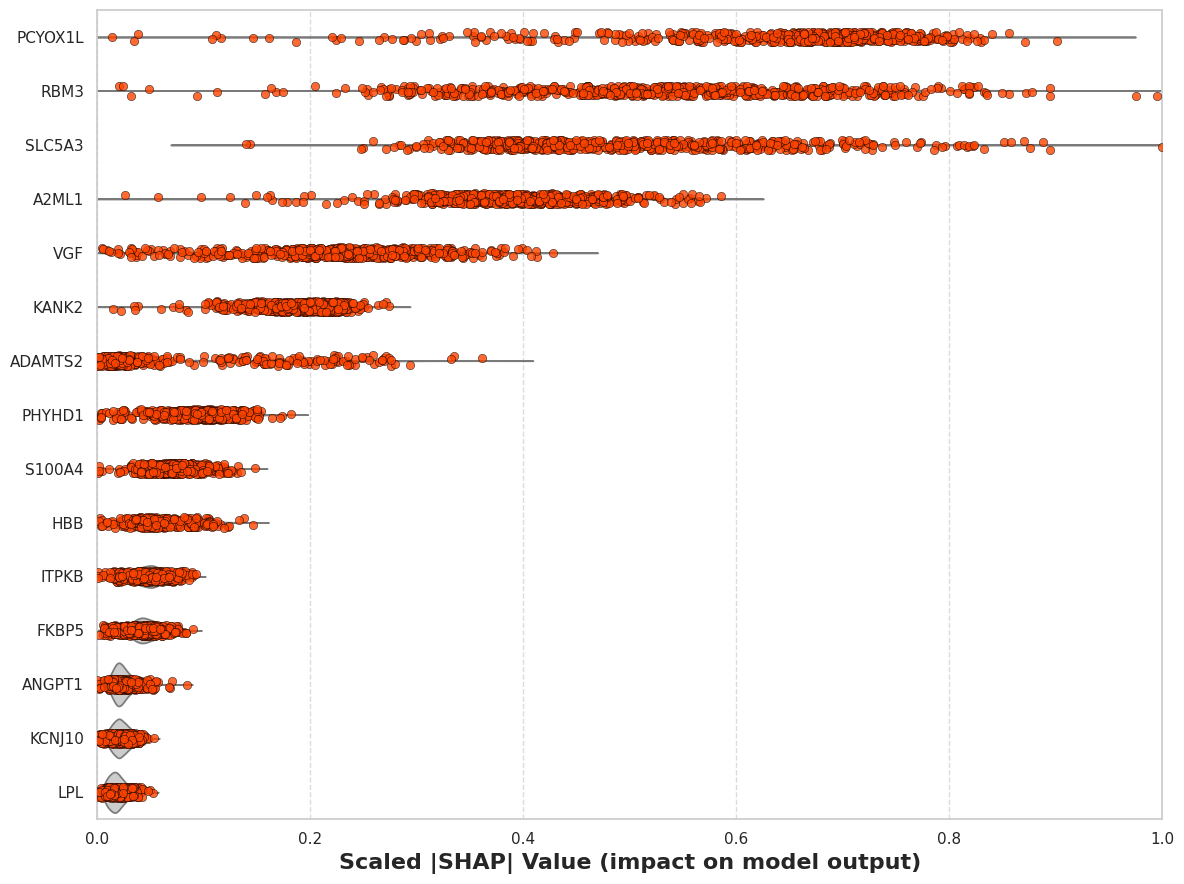

In [37]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assume 'shap_values' is your dictionary with sample IDs and gene SHAP values

# Prepare the data for plotting
data = []
min_value = float('inf')
max_value = float('-inf')

# Collect data and find min and max for scaling
for sample_id, gene_values in shap_values.items():
    for gene, value in gene_values.items():
        if gene in genes_of_interest:
            min_value = min(min_value, value)
            max_value = max(max_value, value)
            data.append({'Sample': sample_id, 'Gene': gene, 'SHAP Value': value})

# Normalize SHAP values to be between 0 and 1
for item in data:
    item['SHAP Value'] = (item['SHAP Value'] - min_value) / (max_value - min_value) if max_value > min_value else 0

df = pd.DataFrame(data)

# Set the style and context
sns.set(style="whitegrid")

# Create the plot
plt.figure(figsize=(12, 9))
sns.violinplot(x='SHAP Value', y='Gene', data=df, inner=None, color="0.8", order=genes_of_interest)
sns.stripplot(x='SHAP Value', y='Gene', data=df, jitter=True, size=6, color='orangered', order=genes_of_interest, edgecolor="black", linewidth=0.4, alpha=0.8)

# Customize the axes and title
plt.xlabel('Scaled |SHAP| Value (impact on model output)', fontsize=16, weight='bold')
plt.ylabel('', fontsize=18, weight='bold')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.xlim(0, 1)  # Ensure the x-axis goes from 0 to 1 for normalization

# Improve the layout
plt.tight_layout()

plt.savefig('./figures/shap_values_plot_density.png', dpi=1200)

# Show the plot
plt.show()


### 2. Subtissue/cluster specific (heatmap)

In [2]:
import pandas as pd
df = pd.read_csv('rnaseq_meta_with_clusters.csv', index_col=0)
df

,individualID,diagnosis,tissue,clusters,race,spanish,apoe4_allele,sex,batch,pmi,...,UNC5C,NRF1,AP2A2,SPPL2A,C14orf93,ENAH,ADAM10,RERE,WDR12,HP1BP3
specimenID,,,,,,,,,,,,,,,,,,,,,
hB_RNA_4411,AMPAD_MSSM_0000077445,1,5,5_3,1.0,2.0,1,1,14,6.583333,...,0.077432,0.023071,0.250745,-0.048598,0.151551,0.121676,0.072142,0.052826,-0.301415,-0.022559
hB_RNA_12484,AMPAD_MSSM_0000034015,1,4,4_1,1.0,2.0,1,1,20,5.250000,...,0.079604,-0.092493,-0.268295,0.201415,0.265450,0.210355,0.179480,-0.062120,0.158489,0.110859
hB_RNA_16295,AMPAD_MSSM_0000083367,1,5,5_2,1.0,2.0,0,0,5,15.250000,...,0.059098,-0.065125,-0.024544,0.179258,-0.193648,0.221193,0.139738,0.007242,-0.216591,-0.037546
BM_10_674,AMPAD_MSSM_0000098979,1,4,4_3,1.0,2.0,0,1,21,19.333333,...,0.053319,0.051089,0.243113,-0.013729,0.076680,0.040974,-0.075280,0.117740,-0.220280,0.297069
hB_RNA_16665,AMPAD_MSSM_0000034450,1,5,5_3,1.0,2.0,0,1,6,3.583333,...,0.163797,-0.023559,0.142141,0.081714,0.299482,0.204516,0.034744,0.028201,-0.244058,0.043588
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hB_RNA_7775,AMPAD_MSSM_0000077061,1,8,8_3,9.0,1.0,0,1,7,5.500000,...,0.227808,0.125087,0.068986,0.033116,0.061294,0.203872,0.185485,0.077594,-0.224639,0.086423
BM_36_545,AMPAD_MSSM_0000076188,1,7,7_4,1.0,2.0,0,0,18,5.733333,...,0.222746,-0.045611,-0.028724,0.164904,0.290218,0.224654,0.197079,0.046552,-0.363716,0.126248
Sample_R6636386-AC,R6636386,1,1,1_3,1.0,2.0,0,0,13,19.500000,...,0.525014,0.223469,-0.145160,0.098366,0.288991,0.131782,0.202997,0.242757,-0.220776,0.212225


In [3]:
import pickle
# Load the dictionary from the pickle file
with open('shap_sample_genes.pkl', 'rb') as f:
    specimen_genes_dict = pickle.load(f)
specimen_genes_dict
# Assuming the dictionary is named specimen_genes_dict and is already loaded
number_of_samples = len(specimen_genes_dict)

print("Number of samples:", number_of_samples)   

Number of samples: 722


In [ ]:
# first get the list of genes common in each cluster
import pandas as pd
import pickle

# Load the dictionary from the pickle file
with open('shap_sample_genes.pkl', 'rb') as f:
    specimen_genes_dict = pickle.load(f)

# Load the DataFrame
df = pd.read_csv('rnaseq_meta_with_clusters.csv', index_col=0)

# Mapping of numeric codes to tissue names
tissue_names = {
    '1': 'ACC',
    '2': 'CBE',
    '3': 'DLFPC',
    '4': 'FP',
    '5': 'IFG',
    '6': 'PCC',
    '7': 'PHG',
    '8': 'STG',
    '9': 'TCX'
}

# Prepare to track the intersection of genes in each cluster
clusters = {}

# Iterate over each cluster group in the DataFrame
for cluster, group in df.groupby('clusters'):
    # Decode the cluster name
    parts = cluster.split('_')
    tissue_code = parts[0]
    tissue_name = tissue_names.get(tissue_code, 'Unknown')
    cluster_label = f"{tissue_name} {parts[1]}"

    # Get the list of specimen IDs for the current cluster
    specimen_ids = group.index.to_list()

    # Initialize a set for the intersection of genes for the first specimen ID, if it exists in the dictionary
    common_genes = set(specimen_genes_dict.get(specimen_ids[0], []))

    # Intersect the genes lists of all other specimen IDs in the cluster
    for specimen_id in specimen_ids[1:]:
        if specimen_id in specimen_genes_dict:
            common_genes.intersection_update(specimen_genes_dict[specimen_id])

    # Store the common genes for the current cluster
    clusters[cluster_label] = list(common_genes)

# Print the formatted clusters dictionary
print("clusters = {")
for cluster, genes in clusters.items():
    print(f"    '{cluster}': {genes},")
print("}")


clusters = {
    'ACC 1': ['S100A4', 'PLPPR1', 'SLC5A3', 'DHRS11', 'PIRT', 'KCNJ10', 'NWD1', 'MT1F', 'A2ML1', 'SLC7A2', 'ZBTB16', 'ENOSF1', 'PPDPF', 'SLC25A48', 'HBA2', 'WDR76', 'HBB', 'SMIM10L2B', 'PCYOX1L', 'SLC16A6', 'EPCIP', 'IGSF3', 'ARL17B', 'CNTNAP5-DT', 'LINC01736', 'PRMT8', 'EIF2AK3-DT', 'KANK2', 'C2orf88', 'PFKP', 'GLI1', 'HBA1', 'GOLGA8B', 'AQP6', 'MEIS3', 'EMP3', 'LOC116435278', 'ADPGK-AS1', 'APLN', 'SLC6A9', 'COL9A1', 'ADAMTS2', 'IRS1', 'LPL', 'ANGPT1', 'SMIM10L2A'],
    'ACC 2': ['S100A4', 'SLC5A3', 'A2ML1', 'MDH1B', 'CSRP1', 'SLC25A48', 'SPRED3', 'SMIM10L2B', 'PCYOX1L', 'MDGA1', 'LINC01736', 'ROBO2', 'VGF', 'SVOP', 'KANK2', 'TRIP10', 'GAREM2', 'ITGA10', 'B3GAT1-DT', 'SLC4A11', 'RBM3'],
    'ACC 3': ['S100A4', 'SSC5D', 'CSRP1', 'SVOP', 'VGF', 'SPRED3', 'PCP4L1', 'KANK2', 'SMIM10L2B', 'TRIP10', 'KCNJ10', 'GAREM2', 'PRELP', 'A2ML1', 'IGSF3', 'AQP6', 'ITPKB', 'SLC6A12'],
    'ACC 4': ['SSC5D', 'SLC25A48', 'VGF', 'KANK2', 'DUSP1', 'SLC5A3', 'TRIP10', 'PIRT', 'ST6GAL2', 'A2ML1

In [ ]:
clusters = {
    'ACC 1': ['S100A4', 'PLPPR1', 'SLC5A3', 'DHRS11', 'PIRT', 'KCNJ10', 'NWD1', 'MT1F', 'A2ML1', 'SLC7A2', 'ZBTB16', 'ENOSF1', 'PPDPF', 'SLC25A48', 'HBA2', 'WDR76', 'HBB', 'SMIM10L2B', 'PCYOX1L', 'SLC16A6', 'EPCIP', 'IGSF3', 'ARL17B', 'CNTNAP5-DT', 'LINC01736', 'PRMT8', 'EIF2AK3-DT', 'KANK2', 'C2orf88', 'PFKP', 'GLI1', 'HBA1', 'GOLGA8B', 'AQP6', 'MEIS3', 'EMP3', 'LOC116435278', 'ADPGK-AS1', 'APLN', 'SLC6A9', 'COL9A1', 'ADAMTS2', 'IRS1', 'LPL', 'ANGPT1', 'SMIM10L2A'],
    'ACC 2': ['S100A4', 'SLC5A3', 'A2ML1', 'MDH1B', 'CSRP1', 'SLC25A48', 'SPRED3', 'SMIM10L2B', 'PCYOX1L', 'MDGA1', 'LINC01736', 'ROBO2', 'VGF', 'SVOP', 'KANK2', 'TRIP10', 'GAREM2', 'ITGA10', 'B3GAT1-DT', 'SLC4A11', 'RBM3'],
    'ACC 3': ['S100A4', 'SSC5D', 'CSRP1', 'SVOP', 'VGF', 'SPRED3', 'PCP4L1', 'KANK2', 'SMIM10L2B', 'TRIP10', 'KCNJ10', 'GAREM2', 'PRELP', 'A2ML1', 'IGSF3', 'AQP6', 'ITPKB', 'SLC6A12'],
    'ACC 4': ['SSC5D', 'SLC25A48', 'VGF', 'KANK2', 'DUSP1', 'SLC5A3', 'TRIP10', 'PIRT', 'ST6GAL2', 'A2ML1', 'EPCIP', 'B3GAT1-DT'],
    'CBE 1': ['NRIP2', 'SLC5A3', 'KCNJ10', 'PIRT', 'NWD1', 'PRKX', 'TEAD2', 'PRELP', 'SLC7A2', 'AHNAK', 'SLC25A48', 'GMPR', 'DUSP1', 'SSC5D', 'SVOP', 'VGF', 'SLCO4A1', 'KANK2', 'APLNR', 'TRIP10', 'FKBP5', 'PHYHD1', 'SLC6A12', 'BEX5', 'SLC4A11', 'ANGPT1', 'SNAP25-AS1', 'RBM3'],
    'CBE 2': ['S100A4', 'PLK4', 'SLC5A3', 'DHRS11', 'PIRT', 'KCNJ10', 'NWD1', 'MT1F', 'CD38', 'PRELP', 'A2ML1', 'DDIT4L', 'TEAD2', 'SLC7A2', 'MDH1B', 'ARMCX5', 'AHNAK', 'CSRP1', 'RAPGEF4', 'SLC25A48', 'MILIP', 'SAMD4A', 'HBA2', 'WDR76', 'GFOD1', 'SPRED3', 'GOLGA7B', 'DUSP1', 'SMIM10L2B', 'KCNE4', 'PCYOX1L', 'SLC16A6', 'LINC01310', 'NPNT', 'LINC01736', 'SVOP', 'MIR9-1HG', 'EIF2AK3-DT', 'SLCO4A1', 'KANK2', 'C2orf88', 'PFKP', 'TRIP10', 'THCAT155', 'GAREM2', 'HBA1', 'MEIS3', 'EMP3', 'ITGA10', 'RHCE', 'SLC6A9', 'RRAD', 'GPRASP2', 'SPATA31H1', 'ANGPT1', 'RBM3'],
    'CBE 3': ['INHBA-AS1', 'NRIP2', 'SLC5A3', 'KCNJ10', 'PIRT', 'SCG2', 'MT1F', 'PRELP', 'MDH1B', 'ARMCX5', 'AHNAK', 'SAMD4A', 'GOLGA7B', 'DDX11', 'SMIM10L2B', 'PCYOX1L', 'TTTY14', 'MDGA1', 'EPCIP', 'IGSF3', 'LNCOC1', 'PPEF1', 'SVOP', 'EIF2AK3-DT', 'C2orf88', 'KANK2', 'TRIP10', 'GAREM2', 'GLI1', 'AQP6', 'ITGA10', 'EMP3', 'SLC6A12', 'SLC4A11', 'SLC6A9', 'GPRASP2', 'FBLN2', 'SLC39A11', 'SPATA31H1', 'ANGPT1', 'RBM3'],
    'CBE 4': ['S100A4', 'CHRDL1', 'DDIT4L', 'SLC7A2', 'CSRP1', 'HBA2', 'HSD17B8', 'HSD11B2', 'AGFG2', 'ARL17B', 'ITPKB', 'LINC01736', 'SSC5D', 'RALY-AS1', 'SPRY4', 'ADPGK-AS1', 'MSR1', 'ANGPT1', 'SST', 'KCNJ10', 'MT1F', 'SAMD4A', 'DIO2', 'DDX11', 'KCNK9', 'MDGA1', 'IGSF3', 'CNTNAP5-DT', 'JAG1', 'SCIN', 'ANGPT2', 'SVOP', 'EIF2AK3-DT', 'GAREM2', 'MPO', 'B3GAT1-DT', 'RRAD', 'PADI2', 'TRIM47', 'PIRT', 'FAM106A', 'SLC25A48', 'SPRED3', 'ENPEP', 'VGF', 'SEMA3C', 'C2orf88', 'PFKP', 'TRIP10', 'KCNF1', 'HBA1', 'AQP6', 'FKBP5', 'APLN', 'SLC6A9', 'SLC4A11', 'PASK', 'QDPR', 'PDE10A', 'APOBR', 'NRIP2', 'LRRC55', 'PCP4L1', 'SLC5A3', 'TEAD2', 'CHST6', 'SDSL', 'DUSP1', 'DUSP4', 'PTPRU', 'EPCIP', 'STEAP3', 'SLCO4A1', 'EGR4', 'EMP3', 'ITGA10', 'SLC6A12', 'RHCE', 'DUSP6', 'RBM3'],
    'DLFPC 1': ['NRIP2', 'INHBA-AS1', 'CD38', 'SCG2', 'FANCE', 'ALDH1A1', 'WDR76', 'SDSL', 'GFOD1', 'PTPRU', 'ROBO2', 'THCAT155', 'KCNF1', 'TTC23-AS1', 'AQP6', 'RIDA', 'SLC4A11', 'SLC6A9', 'ADAMTS2', 'FBLN2', 'PDE10A', 'APOBR', 'IRS1', 'LPL', 'SNAP25-AS1', 'SST'],
    'DLFPC 2': ['PCP4L1', 'C4orf19', 'SLC5A3', 'CHRDL1', 'SCG2', 'SLC7A2', 'MDH1B', 'ZBTB16', 'SLC25A48', 'GFOD1', 'PTPRU', 'SLC16A6', 'EPCIP', 'ROBO2', 'PRMT8', 'PFKP', 'THCAT155', 'KCNF1', 'MOXD1', 'LOC116435278', 'RHCE', 'ADAMTS2', 'PDE10A', 'LPL', 'SNAP25-AS1', 'SST'],
    'DLFPC 3': ['GFOD1', 'ROBO2', 'INSYN2A', 'PFKP', 'CD38', 'PIRT', 'KCNF1', 'PTPRU', 'SCG2', 'THCAT155', 'PDE10A', 'NGB', 'LPL', 'LOC116435278', 'SST'],
    'DLFPC 4': ['CRH', 'PCP4L1', 'CD38', 'SCG2', 'SLC7A2', 'MDH1B', 'FANCE', 'SAMD4A', 'GFOD1', 'SPRED3', 'PTPRU', 'HSPB7', 'EPCIP', 'ROBO2', 'VGF', 'PRMT8', 'PADI2', 'KANK2', 'SLCO4A1', 'EIF2AK3-DT', 'THCAT155', 'KCNF1', 'TTC23-AS1', 'LOC116435278', 'SLC6A12', 'GAD1', 'ADAMTS2', 'PDE10A', 'IRS1', 'LPL', 'SST'],
    'FP 1': ['PIRT', 'LINC00499', 'SLC5A3', 'EPCIP'],
    'FP 2': ['S100A4', 'SSC5D', 'LINC00499', 'VGF', 'SLC5A3', 'ANGPT1'],
    'FP 3': ['LINC00499', 'SLC4A11', 'NWD1', 'PIRT', 'CNTNAP5-DT'],
    'FP 4': ['INHBA-AS1', 'PCP4L1', 'A4GALT', 'SLC5A3', 'DHRS11', 'NWD1', 'PIRT', 'ST6GAL2', 'PRELP', 'COL24A1', 'SLC7A2', 'AHNAK', 'SLC25A48', 'LINC00499', 'GMPR', 'DUSP1', 'NPNT', 'EPCIP', 'IGSF3', 'ITPKB', 'PPEF1', 'SSC5D', 'ROBO2', 'VGF', 'SVOP', 'KCNF1', 'MEIS3', 'FKBP5', 'EMP3', 'PHYHD1', 'ANGPT1'],
    'IFG 1': ['S100A4', 'PCP4L1', 'KCNJ10', 'PIRT', 'NWD1', 'ST6GAL2', 'SCG2', 'CSRP1', 'AHNAK', 'SLC25A48', 'LINC00499', 'SAMD4A', 'DUSP1', 'PCYOX1L', 'HSPB7', 'NPNT', 'LTF', 'IGSF3', 'CNTNAP5-DT', 'ITPKB', 'SSC5D', 'STEAP3', 'ANGPT2', 'ROBO2', 'VGF', 'SVOP', 'PRMT8', 'KANK2', 'TRIP10', 'GAREM2', 'FKBP5', 'LOC116435278', 'BEX5', 'SLC4A11', 'GPRASP2', 'ANGPT1'],
    'IFG 2': ['SLC25A48', 'PCP4L1', 'KANK2', 'ADAMTS2', 'PRELP', 'A2ML1', 'EPCIP', 'ANGPT1', 'RBM3'],
    'IFG 3': ['SSC5D', 'SLC25A48', 'SLC6A9', 'NWD1', 'PIRT', 'RBM3', 'NPNT', 'IGSF3', 'ITGA10', 'ANGPT1', 'ITPKB'],
    'IFG 4': ['CRH', 'PCP4L1', 'NWD1', 'PIRT', 'ST6GAL2', 'MT1F', 'PRELP', 'CSRP1', 'AHNAK', 'SLC25A48', 'DUSP1', 'PCYOX1L', 'SLC16A6', 'MDGA1', 'CNTNAP5-DT', 'ITPKB', 'GALR1', 'ANGPT2', 'ROBO2', 'KANK2', 'APLNR', 'ITGA10', 'SLC6A12', 'BEX5', 'APLN', 'SLC6A9', 'GPRASP2', 'ANGPT1', 'RBM3'],
    'PCC 1': ['S100A4', 'TNFRSF11B', 'MYCBPAP', 'INHBA-AS1', 'PCP4L1', 'SLC5A3', 'CD38', 'CHRDL1', 'PLCXD2', 'SCG2', 'PRELP', 'SLC7A2', 'MDH1B', 'FANCE', 'PRDM16-DT', 'COL21A1', 'ALDH1A1', 'SAMD4A', 'HBA2', 'WDR76', 'SDSL', 'GFOD1', 'GOLGA7B', 'SST', 'PTPRU', 'SLC16A6', 'EPCIP', 'LTF', 'ARL17B', 'LOC105376654', 'ANGPT2', 'SLCO4A1', 'EIF2AK3-DT', 'PFKP', 'FBN3', 'THCAT155', 'KCNF1', 'TTC23-AS1', 'MOXD1', 'RHCE', 'LOC116435278', 'APLN', 'SLC6A9', 'PDYN', 'ADAMTS2', 'COL9A1', 'NGB', 'FBLN2', 'PDE10A', 'APOBR', 'IRS1', 'LPL', 'SNAP25-AS1', 'RBM3'],
    'PCC 2': ['S100A4', 'PLPPR1', 'PCP4L1', 'C4orf19', 'SLC5A3', 'CHRDL1', 'SCG2', 'TEAD2', 'SLC7A2', 'MDH1B', 'PRDM16-DT', 'PPDPF', 'COL21A1', 'ALDH1A1', 'SAMD4A', 'HBA2', 'SLC25A48', 'SDSL', 'GFOD1', 'PTPRU', 'EPCIP', 'LINC01736', 'LOC105376654', 'ROBO2', 'PRMT8', 'KANK2', 'PFKP', 'TRIP10', 'THCAT155', 'KCNF1', 'MOXD1', 'FBN3', 'HBA1', 'GLI1', 'RIDA', 'ITGA10', 'LOC116435278', 'RHCE', 'SLC4A11', 'ADAMTS2', 'NGB', 'PDE10A', 'APOBR', 'LPL', 'ANGPT1', 'SNAP25-AS1', 'SST'],
    'PCC 3': ['PCP4L1', 'C4orf19', 'CD38', 'SCG2', 'MDH1B', 'FANCE', 'PRDM16-DT', 'PPDPF', 'COL21A1', 'SLC25A48', 'WDR76', 'SDSL', 'GFOD1', 'PTPRU', 'TOMM70', 'LOC105376654', 'ROBO2', 'MIR9-1HG', 'EIF2AK3-DT', 'PFKP', 'THCAT155', 'KCNF1', 'GAREM2', 'AQP6', 'RIDA', 'IRS1', 'RHCE', 'SLC6A12', 'ADPGK-AS1', 'APLN', 'SLC6A9', 'PDYN', 'APLF', 'NGB', 'PDE10A', 'PADI2', 'LPL', 'SNAP25-AS1', 'SST'],
    'PCC 4': ['S100A4', 'CRH', 'INHBA-AS1', 'LRRC55', 'PCP4L1', 'C4orf19', 'SCG2', 'MT1F', 'MDH1B', 'AHNAK', 'FANCE', 'PRDM16-DT', 'RERG', 'ALDH1A1', 'WDR76', 'SDSL', 'GFOD1', 'SPRED3', 'PTPRU', 'HSPB7', 'NPNT', 'EPCIP', 'CNTNAP5-DT', 'IRAK2', 'ANGPT2', 'ROBO2', 'VGF', 'MIR9-1HG', 'PRMT8', 'KANK2', 'FBN3', 'THCAT155', 'KCNF1', 'AQP6', 'RIDA', 'KCNAB1', 'RHCE', 'SLC6A12', 'LOC116435278', 'SLC4A11', 'ADAMTS2', 'NGB', 'COLEC12', 'PDE10A', 'LPL', 'SNAP25-AS1', 'SST'],
    'PHG 1': ['SSC5D', 'SLC25A48', 'SAMD4A', 'SLC4A11', 'NWD1', 'PCYOX1L', 'TEAD2', 'PDE10A', 'LTF', 'ITPKB', 'RBM3'],
    'PHG 2': ['PCP4L1', 'SLC5A3', 'KCNJ10', 'DHRS11', 'PIRT', 'NWD1', 'SCG2', 'TEAD2', 'PRELP', 'DDIT4L', 'PRKX', 'SLC7A2', 'AHNAK', 'PAK1', 'LINC00499', 'SAMD4A', 'CHST6', 'SPRED3', 'SMIM10L2B', 'KCNE4', 'PCYOX1L', 'NPNT', 'ARL17B', 'SH2D5', 'ITPKB', 'CNTNAP5-DT', 'SCIN', 'ANGPT2', 'SVOP', 'VGF', 'ROBO2', 'PRMT8', 'CHL1', 'KCNF1', 'MEIS3', 'FKBP5', 'B3GAT1-DT', 'GEM', 'SLC4A11', 'QDPR', 'GPRASP2', 'PDE10A', 'ANGPT1'],
    'PHG 3': ['S100A4', 'PCP4L1', 'A4GALT', 'KCNJ10', 'DHRS11', 'PIRT', 'NWD1', 'TEAD2', 'PRELP', 'SLC7A2', 'CSRP1', 'AHNAK', 'ARMCX5', 'SLC25A48', 'SAMD4A', 'GMPR', 'CHST6', 'DUSP1', 'SMIM10L2B', 'KCNE4', 'PCYOX1L', 'AGFG2', 'NPNT', 'ITPKB', 'PPEF1', 'SSC5D', 'STEAP3', 'SCIN', 'ANGPT2', 'SVOP', 'ROBO2', 'PRMT8', 'KANK2', 'TRIP10', 'GAREM2', 'GOLGA8B', 'FKBP5', 'EMP3', 'PHYHD1', 'BEX5', 'GAD1', 'APLN', 'SLC4A11', 'GPRASP2', 'COLEC12', 'ANGPT1'],
    'PHG 4': ['ANGPT1', 'APLN', 'CSRP1', 'LINC00499', 'SAMD4A', 'CHST6', 'ROBO2', 'PRMT8', 'GPRASP2', 'DHRS11', 'PCYOX1L', 'PIRT', 'NWD1', 'IGSF3', 'ITPKB', 'AHNAK', 'PHYHD1'],
    'STG 1': ['SLC25A48', 'SVOP', 'ROBO2', 'KCNJ10', 'NWD1', 'CNTNAP5-DT', 'FKBP5', 'RBM3'],
    'STG 2': ['SLC25A48', 'SAMD4A', 'ANGPT2', 'KCNJ10', 'PCYOX1L', 'PRELP', 'EPCIP', 'SLC7A2', 'ANGPT1'],
    'STG 3': ['APLN', 'SLC25A48', 'SAMD4A', 'ROBO2', 'SVOP', 'GPRASP2', 'KCNJ10', 'PCYOX1L', 'PIRT', 'CNTNAP5-DT', 'FKBP5', 'ITPKB'],
    'STG 4': ['PCP4L1', 'KCNJ10', 'PIRT', 'NWD1', 'ST6GAL2', 'MT1F', 'CSRP1', 'AHNAK', 'ARMCX5', 'SLC25A48', 'SAMD4A', 'CHST6', 'PCYOX1L', 'ITPKB', 'ANGPT2', 'ROBO2', 'VGF', 'SVOP', 'PRMT8', 'APLNR', 'MEIS3', 'FKBP5', 'PHYHD1', 'BEX5', 'SLC4A11', 'SLC6A9', 'GPRASP2', 'QDPR', 'DUSP6', 'ANGPT1'],
    'TCX 1': ['S100A4', 'WWTR1', 'TNFRSF11B', 'LRRC55', 'PCP4L1', 'C4orf19', 'A4GALT', 'SLC5A3', 'KCNJ10', 'PRKX', 'NWD1', 'PTTG1IP', 'SCG2', 'TEAD2', 'PRELP', 'A2ML1', 'DDIT4L', 'MT1F', 'SLC7A2', 'FAM106A', 'CSRP1', 'AHNAK', 'FMOD', 'ARMCX5', 'COL21A1', 'SLC25A48', 'ALDH1A1', 'GMPR', 'CHST6', 'SPRED3', 'DUSP1', 'DUSP4', 'PCYOX1L', 'PTPRU', 'AGFG2', 'NPNT', 'EPCIP', 'LTF', 'CNTNAP5-DT', 'ITPKB', 'LINC01736', 'SSC5D', 'TOMM70', 'FOXO4', 'ANGPT2', 'ROBO2', 'SVOP', 'VGF', 'SLCO4A1', 'KANK2', 'PRMT8', 'APLNR', 'TRIP10', 'THCAT155', 'GAREM2', 'OGN', 'IRAK2', 'EMP3', 'PHYHD1', 'SLC6A12', 'BEX5', 'FKBP5', 'GAD1', 'APLN', 'LOC116435278', 'SLC4A11', 'SLC6A9', 'GPRASP2', 'QDPR', 'COLEC12', 'PDE10A', 'LPL', 'RBM3'],
    'TCX 2': ['S100A4', 'WWTR1', 'LRRC55', 'PCP4L1', 'A4GALT', 'KCNJ10', 'NWD1', 'TEAD2', 'MT1F', 'PRELP', 'A2ML1', 'SLC7A2', 'FAM106A', 'AHNAK', 'CSRP1', 'ALDH1A1', 'LINC00499', 'GMPR', 'DUSP1', 'DUSP4', 'KCNE4', 'PCYOX1L', 'NPNT', 'EPCIP', 'ITPKB', 'TOMM70', 'LOC105376654', 'ANGPT2', 'SVOP', 'SLCO4A1', 'PRMT8', 'KANK2', 'APLNR', 'TRIP10', 'THCAT155', 'GAREM2', 'HS6ST1', 'FKBP5', 'EMP3', 'SLC6A12', 'GAD1', 'LOC116435278', 'APLN', 'SLC4A11', 'SLC6A9', 'GPRASP2', 'QDPR', 'PDE10A', 'LPL'],
    'TCX 3': ['S100A4', 'LRRC55', 'CD44', 'C4orf19', 'A4GALT', 'SLC5A3', 'KCNJ10', 'C4B', 'NWD1', 'TEAD2', 'MT1F', 'PRELP', 'A2ML1', 'DDIT4L', 'SLC7A2', 'FAM106A', 'AHNAK', 'CSRP1', 'LINC00499', 'SLC25A48', 'ALDH1A1', 'GRIK1', 'DUSP4', 'KCNE4', 'PCYOX1L', 'NPNT', 'LTF', 'EPCIP', 'ITPKB', 'LINC01736', 'SCIN', 'TOMM70', 'LOC105376654', 'ANGPT2', 'SVOP', 'ROBO2', 'PRMT8', 'IRAK2', 'KANK2', 'SFRP2', 'BACE2', 'TRIP10', 'THCAT155', 'GAREM2', 'HS6ST1', 'FKBP5', 'EMP3', 'PHYHD1', 'SLC6A12', 'GAD1', 'LOC116435278', 'APLN', 'SLC4A11', 'GPRASP2', 'QDPR', 'ADAMTS2', 'PDE10A', 'CALB1', 'LPL'],
    'TCX 4': ['S100A4', 'A4GALT', 'SLC5A3', 'KCNJ10', 'DHRS11', 'NWD1', 'TEAD2', 'MT1F', 'PRELP', 'A2ML1', 'DDIT4L', 'SLC7A2', 'FAM106A', 'MDH1B', 'AHNAK', 'CSRP1', 'ARMCX5', 'SCIRT', 'ALDH1A1', 'LINC00499', 'GMPR', 'SLC25A48', 'CHST6', 'HBB', 'DUSP1', 'DUSP4', 'PCYOX1L', 'PTPRU', 'AGFG2', 'NPNT', 'EPCIP', 'ITPKB', 'LINC01736', 'IRAK2', 'LOC105376654', 'ANGPT2', 'SVOP', 'ROBO2', 'PRMT8', 'SLCO4A1', 'KANK2', 'BACE2', 'TRIP10', 'THCAT155', 'GAREM2', 'TTC23-AS1', 'GAD2', 'AQP6', 'FKBP5', 'EMP3', 'SLC6A12', 'GAD1', 'LOC116435278', 'APLN', 'GEM', 'SLC4A11', 'SLC6A9', 'GPRASP2', 'QDPR', 'ADAMTS2', 'NGB', 'PDE10A', 'LPL', 'RBM3'],
}


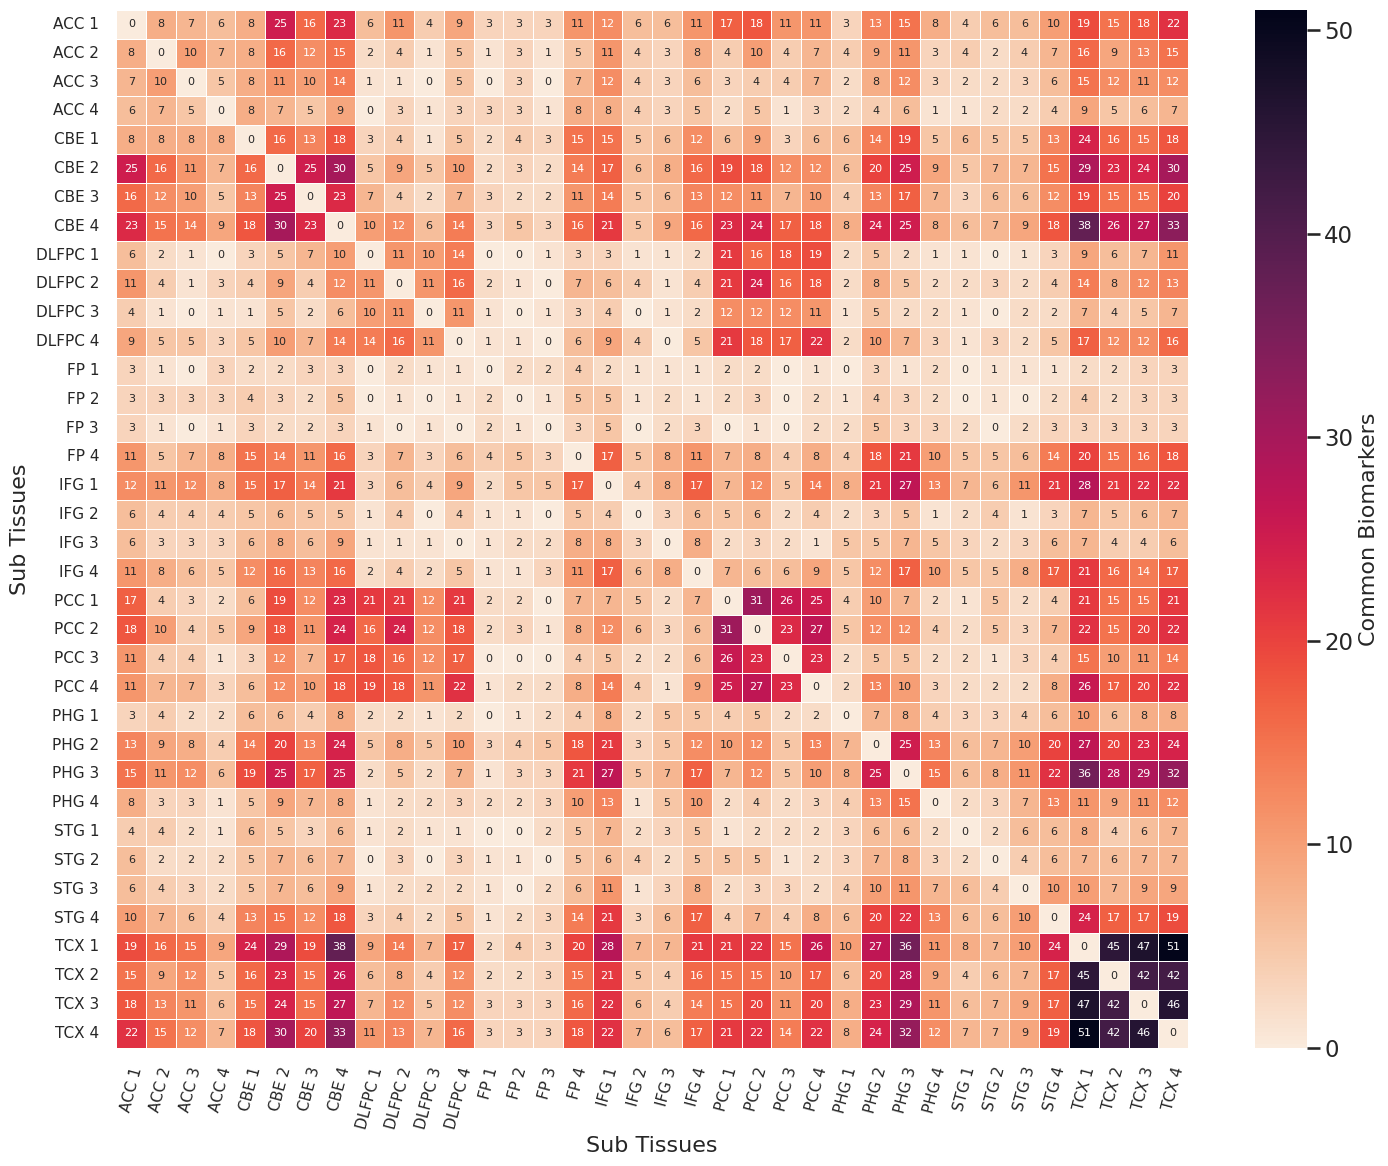

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

# Assuming cluster_sets is already defined as shown in your original code
cluster_sets = {cluster: set(genes) for cluster, genes in clusters.items()}

# Create a matrix for pairwise intersection sizes
clusters_list = list(cluster_sets.keys())
intersection_matrix = pd.DataFrame(index=clusters_list, columns=clusters_list, data=0)

for i in clusters_list:
    for j in clusters_list:
        if i != j:
            intersection_matrix.at[i, j] = len(cluster_sets[i].intersection(cluster_sets[j]))

# Plot the heatmap
plt.figure(figsize=(15, 12))  # Adjust size for better fit
ax = sns.heatmap(intersection_matrix, annot=True, fmt="d", cmap="rocket_r", cbar=True, linewidths=.5, annot_kws={"size": 8},
                 cbar_kws={'label': 'Common biomarkers'})

# Set colorbar label plus label size
cbar = ax.collections[0].colorbar
cbar.set_label('Common Biomarkers', size=16)  # Adjust 'size' to set the font size

# plt.title("Common Genes Among Tissue Subtypes", fontsize=16, weight='bold')
plt.xlabel("Sub Tissues", fontsize=16)
plt.ylabel("Sub Tissues", fontsize=16)
plt.xticks(rotation=75, fontsize=11)  # Smaller font size for x labels
plt.yticks(rotation=0, fontsize=11)  # Smaller font size for y labels

plt.tight_layout()  # Adjust layout to make room for label rotation

# Save the plot with a higher DPI for better quality
plt.savefig('./figures/SHAP_clusters_heatmap.png', dpi=1200)

# Show the plot
plt.show()


### 3. Tissue specific (heatmap)

In [2]:
# first get the list of genes common in each tissue

import pandas as pd
import pickle

# Load the dictionary from the pickle file
with open('shap_sample_genes.pkl', 'rb') as f:
    specimen_genes_dict = pickle.load(f)

# Load the DataFrame
df = pd.read_csv('rnaseq_meta_with_clusters.csv', index_col=0)

# Mapping of numeric codes to tissue names
tissue_names = {
    '1': 'ACC',
    '2': 'CBE',
    '3': 'DLFPC',
    '4': 'FP',
    '5': 'IFG',
    '6': 'PCC',
    '7': 'PHG',
    '8': 'STG',
    '9': 'TCX'
}

# Prepare to track the intersection of genes for each tissue
tissues = {}

# Iterate over each tissue group in the DataFrame
for tissue, group in df.groupby('tissue'):
    # Decode the tissue name
    tissue_name = tissue_names.get(str(tissue))

    # Get the list of specimen IDs for the current tissue
    specimen_ids = group.index.to_list()

    # Initialize a set for the intersection of genes for the first specimen ID, if it exists in the dictionary
    common_genes = set(specimen_genes_dict.get(specimen_ids[0], []))

    # Intersect the genes lists of all other specimen IDs in the tissue
    for specimen_id in specimen_ids[1:]:
        if specimen_id in specimen_genes_dict:
            common_genes.intersection_update(specimen_genes_dict[specimen_id])

    # Store the common genes for the current tissue
    tissues[tissue_name] = list(common_genes)

# Print the formatted tissues dictionary
print("tissues = {")
for tissue, genes in tissues.items():
    print(f"    '{tissue}': {genes},")
print("}")



tissues = {
    'ACC': ['KANK2', 'A2ML1'],
    'CBE': ['RBM3', 'KCNJ10', 'SVOP', 'SLC5A3', 'PIRT', 'ANGPT1', 'TRIP10'],
    'DLFPC': ['PDE10A', 'SCG2', 'PTPRU', 'KCNF1', 'THCAT155', 'SST', 'GFOD1', 'ROBO2', 'LPL'],
    'FP': ['LINC00499'],
    'IFG': ['ANGPT1', 'SLC25A48'],
    'PCC': ['MDH1B', 'PDE10A', 'RHCE', 'SCG2', 'PCP4L1', 'PTPRU', 'KCNF1', 'SNAP25-AS1', 'NGB', 'THCAT155', 'PRDM16-DT', 'SST', 'SDSL', 'GFOD1', 'LPL'],
    'PHG': ['NWD1', 'SAMD4A', 'PCYOX1L', 'ITPKB'],
    'STG': ['KCNJ10', 'SLC25A48'],
    'TCX': ['NWD1', 'PDE10A', 'EMP3', 'FAM106A', 'THCAT155', 'TEAD2', 'A4GALT', 'FKBP5', 'QDPR', 'SVOP', 'EPCIP', 'ANGPT2', 'ALDH1A1', 'GPRASP2', 'TRIP10', 'CSRP1', 'LOC116435278', 'SLC4A11', 'MT1F', 'A2ML1', 'PRELP', 'GAD1', 'SLC7A2', 'KANK2', 'PCYOX1L', 'LPL', 'AHNAK', 'KCNJ10', 'SLC6A12', 'DUSP4', 'APLN', 'NPNT', 'S100A4', 'PRMT8', 'ITPKB', 'GAREM2'],
}


In [5]:
tissues = {
    'ACC': ['A2ML1', 'KANK2'],
    'CBE': ['PIRT', 'ANGPT1', 'TRIP10', 'SVOP', 'RBM3', 'SLC5A3', 'KCNJ10'],
    'DLFPC': ['KCNF1', 'GFOD1', 'PTPRU', 'THCAT155', 'SCG2', 'PDE10A', 'ROBO2', 'SST', 'LPL'],
    'FP': ['LINC00499'],
    'IFG': ['SLC25A48', 'ANGPT1'],
    'PCC': ['KCNF1', 'GFOD1', 'PRDM16-DT', 'RHCE', 'PTPRU', 'SCG2', 'THCAT155', 'PDE10A', 'PCP4L1', 'SNAP25-AS1', 'SDSL', 'SST', 'MDH1B', 'NGB', 'LPL'],
    'PHG': ['PCYOX1L', 'ITPKB', 'NWD1', 'SAMD4A'],
    'STG': ['SLC25A48', 'KCNJ10'],
    'TCX': ['SVOP', 'FAM106A', 'NWD1', 'APLN', 'SLC6A12', 'PCYOX1L', 'CSRP1', 'SLC4A11', 'LOC116435278', 'KCNJ10', 'GAREM2', 'A4GALT', 'NPNT', 'EPCIP', 'DUSP4', 'PDE10A', 'ALDH1A1', 'ANGPT2', 'MT1F', 'PRMT8', 'GAD1', 'S100A4', 'SLC7A2', 'GPRASP2', 'ITPKB', 'EMP3', 'A2ML1', 'THCAT155', 'TRIP10', 'TEAD2', 'KANK2', 'FKBP5', 'QDPR', 'AHNAK', 'PRELP', 'LPL'],
}

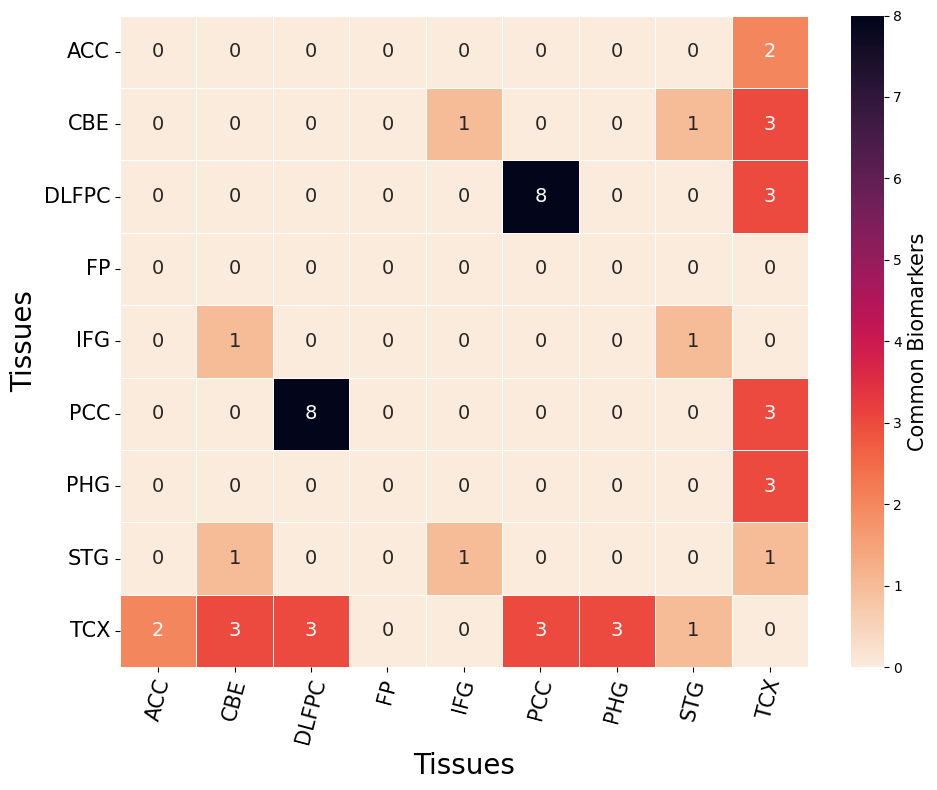

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

# Assuming cluster_sets is already defined as shown in your original code
cluster_sets = {cluster: set(genes) for cluster, genes in tissues.items()}

# Create a matrix for pairwise intersection sizes
clusters_list = list(cluster_sets.keys())
intersection_matrix = pd.DataFrame(index=clusters_list, columns=clusters_list, data=0)

for i in clusters_list:
    for j in clusters_list:
        if i != j:
            intersection_matrix.at[i, j] = len(cluster_sets[i].intersection(cluster_sets[j]))

# Plot the heatmap
plt.figure(figsize=(10, 8))  # Adjust size for better fit
ax = sns.heatmap(intersection_matrix, annot=True, fmt="d", cmap="rocket_r", cbar=True, linewidths=.6, annot_kws={"size": 14},
                 cbar_kws={'label': 'Common biomarkers'})

# Set colorbar label plus label size
cbar = ax.collections[0].colorbar
cbar.set_label('Common Biomarkers', size=15)  # Adjust 'size' to set the font size

# plt.title("Common Genes Among Tissue Subtypes", fontsize=16, weight='bold')
plt.xlabel("Tissues", fontsize=20)
plt.ylabel("Tissues", fontsize=20)
plt.xticks(rotation=75, fontsize=15)  # Smaller font size for x labels
plt.yticks(rotation=0, fontsize=15)  # Smaller font size for y labels

plt.tight_layout()  # Adjust layout to make room for label rotation

# Save the plot with a higher DPI for better quality
plt.savefig('./figures/SHAP_tissues_heatmap.png', dpi=1200)

# Show the plot
plt.show()


## 3. Volcano plot

In [14]:
import numpy as np
import pandas as pd
df = pd.read_csv("./differential_expression_results_5k.csv", index_col=0)
df

,logFC,AveExpr,t,P.Value,adj.P.Val,B
KANK2,0.453056,-0.061939,20.717272,6.289386e-87,3.144693e-83,187.197481
A2ML1,0.559095,-0.175121,20.051478,5.411257e-82,2.705629e-78,175.911028
SAMD4A,0.385511,-0.129778,19.861149,1.330607e-80,6.653036e-77,172.730371
EMP3,0.473581,-0.204960,19.242383,3.824434e-76,1.912217e-72,162.534466
GAREM2,0.487513,-0.115462,19.144869,1.889235e-75,9.446177e-72,160.948155
...,...,...,...,...,...,...
MAL,-0.000397,0.332032,-0.010818,9.913694e-01,1.000000e+00,-7.355115
ID2,0.000162,0.329911,0.006955,9.944513e-01,1.000000e+00,-7.355149
KCNJ12,-0.000277,-0.200432,-0.006945,9.944593e-01,1.000000e+00,-7.355149
VEGFA,-0.000176,-0.019504,-0.005681,9.954679e-01,1.000000e+00,-7.355157


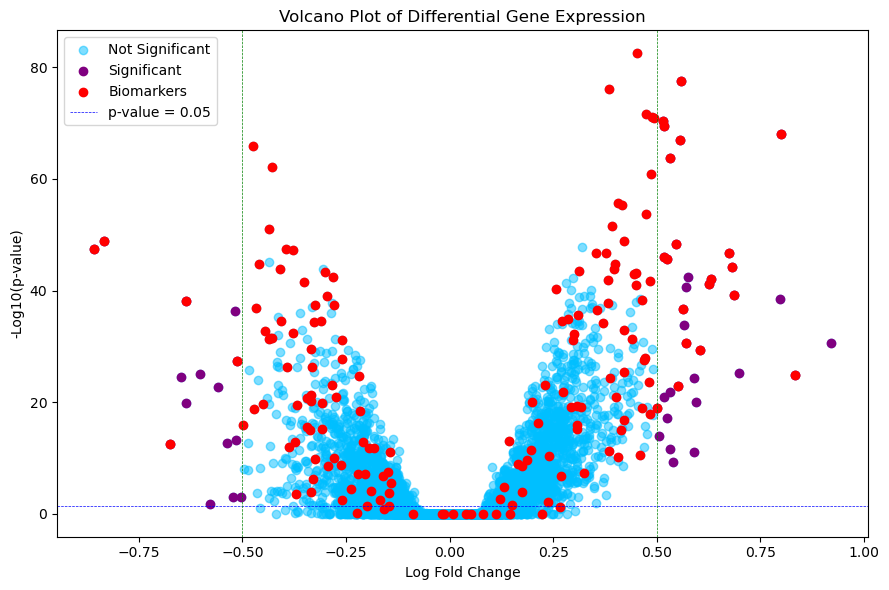

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./differential_expression_results_5k.csv")


# Let's assume df has columns 'logFC', 'P.Value', 'Gene_name'
df['neg_log10_p_value'] = -np.log10(df['adj.P.Val'])

# Highlighted genes
highlight_genes = ['SSC5D', 'RRAD', 'SLC6A9', 'SCIN', 'ARL17B', 'MSR1', 'LTF', 'C2orf88', 'PPEF1', 'MDH1B', 'PIRT', 'MPO', 'COL24A1', 'NGB', 'ALDH1A1', 'PCYOX1L', 'IGSF3', 'AGFG2', 'TRIM47', 'MT1F', 'GLI1', 'DHRS11', 'PRMT8', 'GALR1', 'PRKX', 'PDYN', 'KCNE4', 'FBN3', 'CD38', 'ANGPT1', 'ADPGK-AS1', 'EMP3', 'GRIK1', 'MOXD1', 'GFOD1', 'INSYN2A', 'ENOSF1', 'CHST6', 'COLEC12', 'RIDA', 'SLC5A3', 'BEX5', 'EGR4', 'TTTY14', 'DDX11', 'PLK4', 'FKBP5', 'PTTG1IP', 'GEM', 'ITGA10', 'PDE10A', 'MDGA1', 'VGF', 'TRIP10', 'SPRY4', 'GOLGA8B', 'SLC16A6', 'CHL1', 'CSRP1', 'SFRP2', 'TNFRSF11B', 'PADI2', 'ITPKB', 'LRRC55', 'NPNT', 'ST6GAL2', 'ARMCX5', 'DDIT4L', 'A4GALT', 'APLF', 'RBM3', 'GAD2', 'SCG2', 'LINC01736', 'PPDPF', 'KANK2', 'HBA1', 'GMPR', 'HSPB7', 'IRAK2', 'SMIM10L2B', 'ROBO2', 'MYCBPAP', 'FANCE', 'SST', 'SLC39A11', 'FMOD', 'COL9A1', 'OGN', 'S100A4', 'RHCE', 'DUSP6', 'NRIP2', 'SPRED3', 'TOMM70', 'MIR9-1HG', 'PTPRU', 'C4orf19', 'STEAP3', 'PFKP', 'LOC116435278', 'KCNAB1', 'APOBR', 'SEMA3C', 'PCP4L1', 'CNTNAP5-DT', 'DIO2', 'SVOP', 'LINC01310', 'WDR76', 'ADAMTS2', 'SLCO4A1', 'DUSP1', 'SCIRT', 'GAREM2', 'SLC6A12', 'KCNK9', 'LPL', 'CRH', 'CALB1', 'SNAP25-AS1', 'RAPGEF4', 'LINC00499', 'FBLN2', 'KCNF1', 'TEAD2', 'TTC23-AS1', 'SLC4A11', 'MEIS3', 'ENPEP', 'LOC105376654', 'PLCXD2', 'DUSP4', 'HSD11B2', 'HSD17B8', 'IRS1', 'RERG', 'SPATA31H1', 'KCNJ10', 'EPCIP', 'THCAT155', 'SMIM10L2A', 'HBB', 'FAM106A', 'SLC25A48', 'JAG1', 'GAD1', 'A2ML1', 'LNCOC1', 'QDPR', 'APLN', 'ANGPT2', 'COL21A1', 'AHNAK', 'SH2D5', 'PLPPR1', 'NWD1', 'HS6ST1', 'CD44', 'BACE2', 'APLNR', 'HBA2', 'FOXO4', 'SDSL', 'MILIP', 'SLC7A2', 'WWTR1', 'B3GAT1-DT', 'RALY-AS1', 'PAK1', 'PHYHD1', 'GPRASP2', 'INHBA-AS1', 'AQP6', 'EIF2AK3-DT', 'C4B', 'ZBTB16', 'PASK', 'CHRDL1', 'GOLGA7B', 'PRELP', 'SAMD4A', 'PRDM16-DT']
highlight_genes_shap_tissues = ['CNTNAP5-DT', 'C2orf88', 'EPCIP', 'C2orf88', 'TRIP10', 'S100A4', 'SVOP', 'SLC4A11', 'ITGA10', 'ANGPT1', 'PDE10A', 'GFOD1', 'SST', 'ADAMTS2', 'PLPPR1', 'SPEF1', 'CD38', 'THCAT155', 'PTPRU', 'KCNF1', 'SCG2', 'LPL', 'PIRT', 'C2orf88', 'EPCIP', 'C2orf88', 'CNTNAP5-DT', 'SLC25A48', 'ANGPT1', 'MOXD1', 'GFOD1', 'SST', 'ADAMTS2', 'PLPPR1', 'PDYN', 'SPEF1', 'SNAP25-AS1', 'THCAT155', 'PTPRU', 'KCNF1', 'SCG2', 'ALDH1A1', 'TEAD2', 'PCYOX1L', 'GOLGA8B', 'C2orf88', 'SLC25A48', 'PCYOX1L', 'C2orf88', 'CNTNAP5-DT', 'EPCIP', 'KCNJ10', 'FAM106A', 'KCNE4', 'CSRP1', 'NPNT', 'GEM', 'GAREM2', 'GOLGA8B', 'GAD1', 'TEAD2', 'S100A4', 'ITPKB', 'EMP3', 'NWD1', 'SLC6A9', 'AHNAK', 'PDE10A', 'SLCO4A1', 'MT1F', 'ADAMTS2', 'SLC7A2', 'APLN', 'TTC23-AS1', 'LRRC55', 'THCAT155', 'A4GALT', 'LPL', 'ALDH1A1', 'LOC116435278', 'PRELP', 'TRIP10', 'CRYM', 'SLC4A11', 'PCYOX1L', 'DUSP4']
# Define thresholds for significant logFC and p-values
logfc_threshold = 0.5
pvalue_threshold = 0.05

# Calculate the y-value for the horizontal line (p-value threshold)
pvalue_line = -np.log10(pvalue_threshold)

# Define significance based on thresholds
significant = (df['logFC'].abs() > logfc_threshold) & (df['adj.P.Val'] < pvalue_threshold)

# Plotting
plt.figure(figsize=(9, 6))
# Plot all genes
# Plot all genes
plt.scatter(df['logFC'], df['neg_log10_p_value'], color='deepskyblue', label='Not Significant', alpha=0.5)  # Added alpha for better visibility

# Plot significant genes
plt.scatter(df['logFC'][significant], df['neg_log10_p_value'][significant], color='purple', label='Significant')

# Highlight specific genes
highlighted = df['Unnamed: 0'].isin(highlight_genes)
plt.scatter(df['logFC'][highlighted], df['neg_log10_p_value'][highlighted], color='red', label='Biomarkers')  # Increased size for visibility
# Add a horizontal line at p-value = 0.05
plt.axhline(pvalue_line, color='blue', linestyle='--', linewidth=0.5, label=f'p-value = {pvalue_threshold}')
plt.axvline(-logfc_threshold, color='green', linestyle='--', linewidth=0.5)
plt.axvline(logfc_threshold, color='green', linestyle='--', linewidth=0.5)

plt.title('Volcano Plot of Differential Gene Expression')
plt.xlabel('Log Fold Change')
plt.ylabel('-Log10(p-value)')
plt.legend(loc='upper left')
plt.tight_layout()

# Save the plot as a high-quality image
plt.savefig('./figures/volcano_plot_5k.png', dpi=1200)  # Increase dpi for higher resolution

plt.show()

## 4. GSEA bar plots

The input is from DAVID database for enrichment anlaysis

In [1]:
import pandas as pd
file_path = '/home/vmottaqi/rnaseq_synapse/disease.txt'  # Update this to the path of your .txt file
df = pd.read_csv(file_path, delimiter='\t')  # Assuming tab-delimited file
df_filtered = df[df['Bonferroni'] < 0.05]

df_filtered

,Category,Term,Count,%,PValue,Genes,List Total,Pop Hits,Pop Total,Fold Enrichment,Bonferroni,Benjamini,FDR
0,GAD_DISEASE,asthma,17,5.483871,0.000004,"ENSG00000104112, ENSG00000176697, ENSG00000096...",196,274,12924,4.091092,0.009224,0.009267,0.009255
1,GAD_DISEASE,Coronary Disease|Coronary heart disease,8,2.580645,0.000071,"ENSG00000125538, ENSG00000244734, ENSG00000130...",196,68,12924,7.757503,0.151260,0.081998,0.081891
2,GAD_DISEASE,Alzheimer's Disease,11,3.548387,0.000459,"ENSG00000115594, ENSG00000117594, ENSG00000125...",196,183,12924,3.963533,0.652759,0.299144,0.298755
3,GAD_DISEASE,lupus erythematosus,7,2.258065,0.000642,"ENSG00000146648, ENSG00000180353, ENSG00000126...",196,70,12924,6.593878,0.772525,0.299144,0.298755
4,GAD_DISEASE,Thalassemia,3,0.967742,0.000673,"ENSG00000206172, ENSG00000244734, ENSG00000198734",196,3,12924,65.938776,0.787864,0.299144,0.298755
...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,GAD_DISEASE,"Arthritis, Rheumatoid|Myocardial Ischemia",2,0.645161,0.044588,"ENSG00000164867, ENSG00000007171",196,3,12924,43.959184,1.000000,1.000000,0.999132
99,GAD_DISEASE,Hyperemia,2,0.645161,0.044588,"ENSG00000196839, ENSG00000164867",196,3,12924,43.959184,1.000000,1.000000,0.999132
100,GAD_DISEASE,alpha-Thalassemia|Anemia|Glucosephosphate Dehy...,2,0.645161,0.044588,"ENSG00000206172, ENSG00000244734",196,3,12924,43.959184,1.000000,1.000000,0.999132
101,GAD_DISEASE,Apoplexy|Brain Ischemia|Stroke,4,1.290323,0.045706,"ENSG00000125538, ENSG00000164867, ENSG00000198...",196,53,12924,4.976511,1.000000,1.000000,0.999132


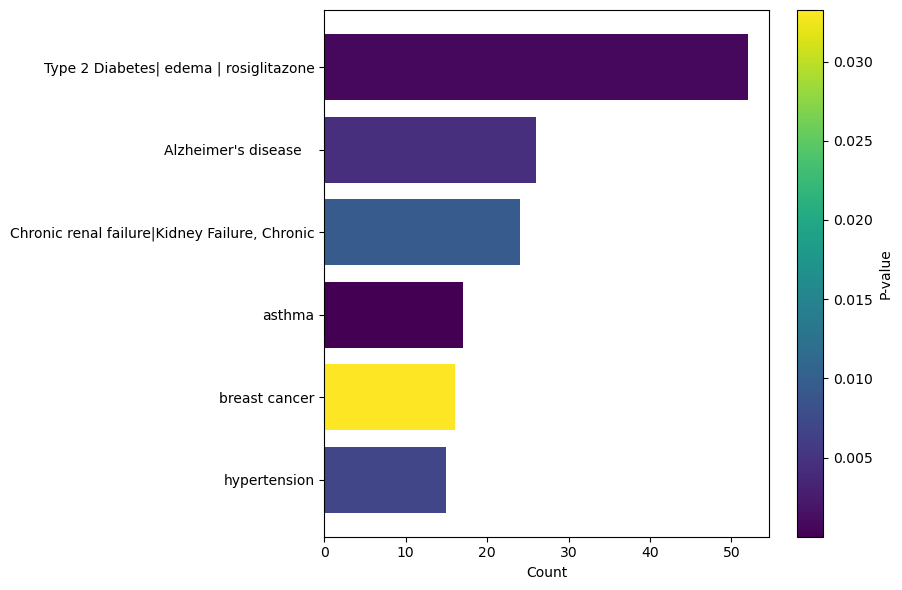

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Sort the dataframe by the 'Count' column in ascending order for visual appeal
df_sorted = df_filtered.sort_values(by='Count', ascending=True)

# Select the top 5 rows
top5 = df_sorted.tail(6)

# Normalize Fisher exact test values for color mapping
norm = mcolors.Normalize(vmin=top5['Bonferroni'].min(), vmax=top5['Bonferroni'].max())
cmap = plt.cm.viridis  # Using a different colormap for better visual differentiation
# plasma

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top5['Term'], top5['Count'], color=cmap(norm(top5['Bonferroni'])))

# Add color bar to indicate Fisher exact test values
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('P-value')

# Set labels and title
ax.set_xlabel('Count')
# ax.set_ylabel('Pathways')
# ax.set_title('Biomarkers Pathways (REACTOME)')

# Adjust layout to ensure no label cutoff
plt.tight_layout()

# Save the figure with high resolution

plt.savefig('/home/vmottaqi/rnaseq_synapse/biomarkers_union_GSEA_DISEASE.png', dpi=1200)

# Show plot
plt.show()



In [ ]:
import pandas as pd
file_path = '/home/vmottaqi/rnaseq_synapse/reactome_shap.txt'  # Update this to the path of your .txt file
df = pd.read_csv(file_path, delimiter='\t')  # Assuming tab-delimited file
df_filtered = df[df['Bonferroni'] < 0.05]
# Remove everything before and including '~' in the 'Term' column
df_filtered['Term'] = df_filtered['Term'].apply(lambda x: x.split('~')[-1])
df_filtered

/tmp/ipykernel_42234/2693630668.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['Term'] = df_filtered['Term'].apply(lambda x: x.split('~')[-1])


,Category,Term,Count,%,PValue,Genes,List Total,Pop Hits,Pop Total,Fold Enrichment,Bonferroni,Benjamini,FDR
0,REACTOME_PATHWAY,Binding and Uptake of Ligands by Scavenger Rec...,6,3.278689,0.000042,"COLEC12, MSR1, HBB, HBA2, SSC5D, HBA1",105,42,11091,15.089796,0.020234,0.010426,0.010426
1,REACTOME_PATHWAY,Defective CHST6 causes MCDC1,4,2.185792,0.000043,"CHST6, OGN, PRELP, FMOD",105,8,11091,52.814286,0.020636,0.010426,0.010426
2,REACTOME_PATHWAY,Keratan sulfate biosynthesis,4,2.185792,0.002213,"CHST6, OGN, PRELP, FMOD",105,28,11091,15.089796,0.655458,0.180578,0.180578
3,REACTOME_PATHWAY,Defective B4GALT1 causes B4GALT1-CDG (CDG-2d),3,1.639344,0.002350,"OGN, PRELP, FMOD",105,8,11091,39.610714,0.677558,0.180578,0.180578
4,REACTOME_PATHWAY,Defective ST3GAL3 causes MCT12 and EIEE15,3,1.639344,0.002350,"OGN, PRELP, FMOD",105,8,11091,39.610714,0.677558,0.180578,0.180578
5,REACTOME_PATHWAY,Nuclear Events (kinase and transcription facto...,5,2.732240,0.002527,"DUSP4, VGF, EGR4, RRAD, DUSP6",105,61,11091,8.658080,0.703908,0.180578,0.180578
6,REACTOME_PATHWAY,Transcriptional Regulation by MECP2,5,2.732240,0.002682,"SST, GAD1, CRH, GAD2, FKBP5",105,62,11091,8.518433,0.725242,0.180578,0.180578
7,REACTOME_PATHWAY,Erythrocytes take up oxygen and release carbon...,3,1.639344,0.003003,"HBB, HBA2, HBA1",105,9,11091,35.209524,0.764678,0.180578,0.180578
8,REACTOME_PATHWAY,Signaling by NTRK1 (TRKA),6,3.278689,0.004472,"DUSP4, VGF, EGR4, IRS1, RRAD, DUSP6",105,115,11091,5.511056,0.884191,0.198226,0.198226
9,REACTOME_PATHWAY,Keratan sulfate/keratin metabolism,4,2.185792,0.004568,"CHST6, OGN, PRELP, FMOD",105,36,11091,11.736508,0.889459,0.198226,0.198226


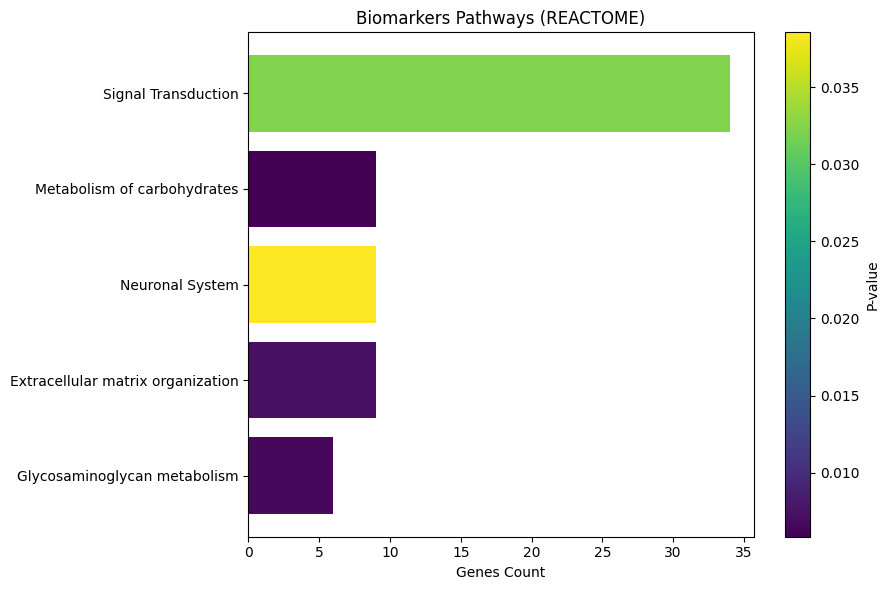

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Sort the dataframe by the 'Count' column in ascending order for visual appeal
df_sorted = df_filtered.sort_values(by='Count', ascending=True)

# Select the top 5 rows
top5 = df_sorted.tail(5)

# Normalize Fisher exact test values for color mapping
norm = mcolors.Normalize(vmin=top5['Bonferroni'].min(), vmax=top5['Bonferroni'].max())
cmap = plt.cm.viridis  # Using a different colormap for better visual differentiation
# plasma

# Create the horizontal bar plot
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(top5['Term'], top5['Count'], color=cmap(norm(top5['Bonferroni'])))

# Add color bar to indicate Fisher exact test values
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('P-value')

# Set labels and title
ax.set_xlabel('Genes Count')
# ax.set_ylabel('Pathways')
ax.set_title('Biomarkers Pathways (REACTOME)')

# Adjust layout to ensure no label cutoff
plt.tight_layout()

# Save the figure with high resolution

plt.savefig('./figures/biomarkers_union_GSEA_REACTOME.png', dpi=1200)

# Show plot
plt.show()



## 5. Bar plots

### Tissue specific biomarkers

/tmp/ipykernel_18858/4069135680.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Tissue', y='Number of Biomarkers', data=df, palette='tab10')


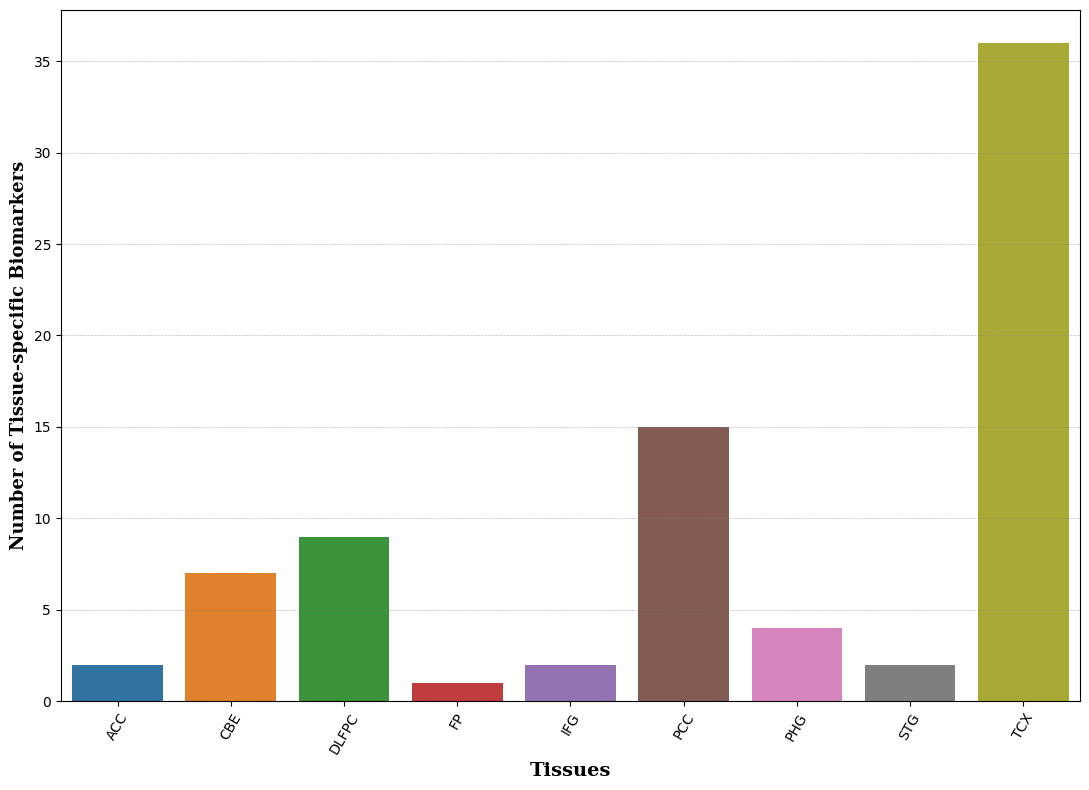

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary of tissues with their respective genes
tissues = {
    'ACC': ['A2ML1', 'KANK2'],
    'CBE': ['PIRT', 'ANGPT1', 'TRIP10', 'SVOP', 'RBM3', 'SLC5A3', 'KCNJ10'],
    'DLFPC': ['KCNF1', 'GFOD1', 'PTPRU', 'THCAT155', 'SCG2', 'PDE10A', 'ROBO2', 'SST', 'LPL'],
    'FP': ['LINC00499'],
    'IFG': ['SLC25A48', 'ANGPT1'],
    'PCC': ['KCNF1', 'GFOD1', 'PRDM16-DT', 'RHCE', 'PTPRU', 'SCG2', 'THCAT155', 'PDE10A', 'PCP4L1', 'SNAP25-AS1', 'SDSL', 'SST', 'MDH1B', 'NGB', 'LPL'],
    'PHG': ['PCYOX1L', 'ITPKB', 'NWD1', 'SAMD4A'],
    'STG': ['SLC25A48', 'KCNJ10'],
    'TCX': ['SVOP', 'FAM106A', 'NWD1', 'APLN', 'SLC6A12', 'PCYOX1L', 'CSRP1', 'SLC4A11', 'LOC116435278', 'KCNJ10', 'GAREM2', 'A4GALT', 'NPNT', 'EPCIP', 'DUSP4', 'PDE10A', 'ALDH1A1', 'ANGPT2', 'MT1F', 'PRMT8', 'GAD1', 'S100A4', 'SLC7A2', 'GPRASP2', 'ITPKB', 'EMP3', 'A2ML1', 'THCAT155', 'TRIP10', 'TEAD2', 'KANK2', 'FKBP5', 'QDPR', 'AHNAK', 'PRELP', 'LPL']
}

# Convert dictionary to a DataFrame suitable for plotting
data = {'Tissue': [], 'Number of Biomarkers': []}
for tissue, genes in tissues.items():
    data['Tissue'].append(tissue)
    data['Number of Biomarkers'].append(len(genes))

df = pd.DataFrame(data)

# Create the bar plot using Seaborn
plt.figure(figsize=(11, 8))
ax = sns.barplot(x='Tissue', y='Number of Biomarkers', data=df, palette='tab10')
# ax.set_title('Number of Shared Biomarkers per Tissue')
ax.set_xlabel('Tissues', fontdict={'size': 14, 'weight': 'bold', 'family': 'serif'})
ax.set_ylabel('Number of Tissue-specific Biomarkers', fontdict={'size': 13, 'weight': 'bold', 'family': 'serif'})
plt.xticks(rotation=60)  # Rotate labels to prevent overlap

# Enable the horizontal grid with opacity
ax.yaxis.grid(True)  # Enable the Y-axis grid lines
ax.grid(True, which='major', axis='y', linestyle='--', linewidth='0.5', color='grey', alpha=0.5)


# Show the plot
plt.tight_layout()

# plt.savefig("./figures/tissues_shap_count_Dec2724.png", dpi=1200)
plt.show()


/tmp/ipykernel_24112/4075583151.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['Total Unique Intermediates'] = clean_df['Total Unique Intermediates'].astype(int)
/tmp/ipykernel_24112/4075583151.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  clean_df['Common SHAP Genes Count'] = clean_df['Common SHAP Genes Count'].astype(int)
/tmp/ipykernel_24112/4075583151.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_in

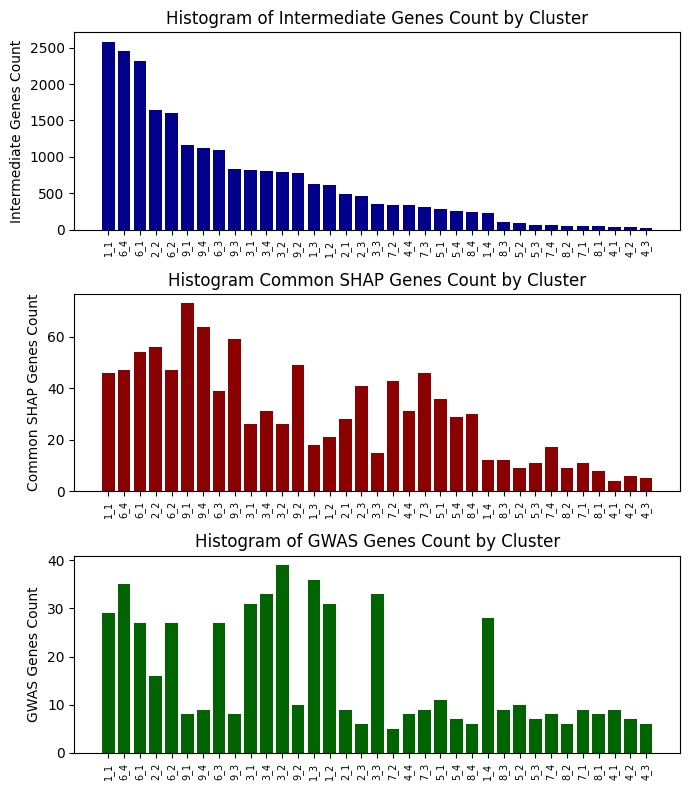

In [ ]:
# One script, three histograms

import pandas as pd
import matplotlib.pyplot as plt

merged_df = pd.read_csv("summary_shap_gwas_intermediates.csv", index_col=0)

# Remove rows where 'Intermediate Genes Count' is NaN
clean_df = merged_df.dropna(subset=['Total Unique Intermediates'])

# Convert 'Intermediate Genes Count' and other columns to integers now that NaNs are removed
clean_df['Total Unique Intermediates'] = clean_df['Total Unique Intermediates'].astype(int)
clean_df['Common SHAP Genes Count'] = clean_df['Common SHAP Genes Count'].astype(int)
clean_df['GWAS Genes Count'] = clean_df['GWAS Genes Count'].astype(int)

# Sort the dataframe by 'Intermediate Genes Count' in descending order
sorted_df = clean_df.sort_values('Total Unique Intermediates', ascending=False)

# Create the first histogram for 'Intermediate Genes Count'
plt.figure(figsize=(7, 8))

# First Histogram
plt.subplot(3, 1, 1)  # three rows, one column, first subplot
plt.bar(sorted_df['Cluster'], sorted_df['Total Unique Intermediates'], color='darkblue')
plt.title('Histogram of Intermediate Genes Count by Cluster')
plt.ylabel('Intermediate Genes Count')
plt.xticks(rotation=90, fontsize=7)  # Rotate the x-axis labels for better visibility

# Second Histogram, use the same cluster order as the first
plt.subplot(3, 1, 2)  # three rows, one column, second subplot
plt.bar(sorted_df['Cluster'], sorted_df['Common SHAP Genes Count'], color='darkred')
plt.title('Histogram Common SHAP Genes Count by Cluster')
plt.ylabel('Common SHAP Genes Count')
plt.xticks(rotation=90, fontsize=7)

# Third Histogram, use the same cluster order as the first
plt.subplot(3, 1, 3)  # three rows, one column, third subplot
plt.bar(sorted_df['Cluster'], sorted_df['GWAS Genes Count'], color='darkgreen')
plt.title('Histogram of GWAS Genes Count by Cluster')
plt.ylabel('GWAS Genes Count')
plt.xticks(rotation=90, fontsize=7)

plt.tight_layout()  # Adjust subplots to give some padding
plt.savefig('./figures/counts_intermediate_gwas_shap.png', dpi=900)
plt.show()


### Subtissue specific gene sets count histograms

Subtissue specific Intermediate genes

In [ ]:
import pandas as pd
df = pd.read_csv("summary_shap_gwas_intermediates.csv", index_col=0)
df.head()

,Cluster,Study,Samples in Cluster,Unique Individuals,Common SHAP Genes Count,Common SHAP Genes,Individuals_gwas,GWAS snps count,GWAS snps,GWAS Genes,GWAS Genes Count,Total Unique Intermediates,Unique Intermediates List
0,1_1,ROSMAP,4,4,46,"['SLC7A2', 'NWD1', 'LPL', 'SLC5A3', 'EMP3', 'L...",2,120,"['rs41281314', 'rs7917781', 'rs55717455', 'rs1...","['CR1', 'FERMT2', 'ZNF423', 'HLA-DQA1', 'KCNQ5...",29,2583.0,"['GALNT7', 'GBP1', 'SLC9A2', 'RPS2', 'RGS8', '..."
1,1_2,ROSMAP,18,18,21,"['SLC5A3', 'TRIP10', 'LINC01736', 'GAREM2', 'B...",13,114,"['rs7903757', 'rs12572738', 'rs10999979', 'rs4...","['PICALM', 'CR1', 'MAP1B', 'BIN1', 'TMEM170B',...",31,611.0,"['SLC9A2', 'TRIM5', 'ANO6', 'DACH1', 'HPCA', '..."
2,1_3,ROSMAP,11,11,18,"['KANK2', 'A2ML1', 'SVOP', 'ITPKB', 'CSRP1', '...",8,128,"['rs4747187', 'rs10902249', 'rs693458', 'rs545...","['PICALM', 'SHARPIN', 'MAP1B', 'BIN1', 'FERMT2...",36,631.0,"['APP', 'GALNT12', 'ANTKMT', 'NDRG1', 'RGS8', ..."
3,1_4,ROSMAP,21,21,12,"['KANK2', 'DUSP1', 'A2ML1', 'PIRT', 'SLC5A3', ...",17,93,"['rs10999882', 'rs74147331', 'rs74147345', 'rs...","['CYP11A1', 'ZNF423', 'HLA-DQA1', 'SUOX', 'KCN...",28,227.0,"['NUDT4', 'GALNT12', 'SYP', 'SELENOP', 'WDR49'..."
4,2_1,MAYO,7,7,28,"['SLC7A2', 'NWD1', 'AHNAK', 'SLC5A3', 'APLNR',...",7,18,"['rs7667050', 'rs7268', 'rs2074613', 'rs340225...","['MLH3', 'ZNF423', 'PPARGC1A', 'HBEGF', 'RORA'...",9,489.0,"['WFIKKN2', 'SAMD11', 'SIGLEC14', 'ST8SIA6', '..."


/tmp/ipykernel_21476/1300899333.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['Cluster_ID'].unique(), rotation=65)


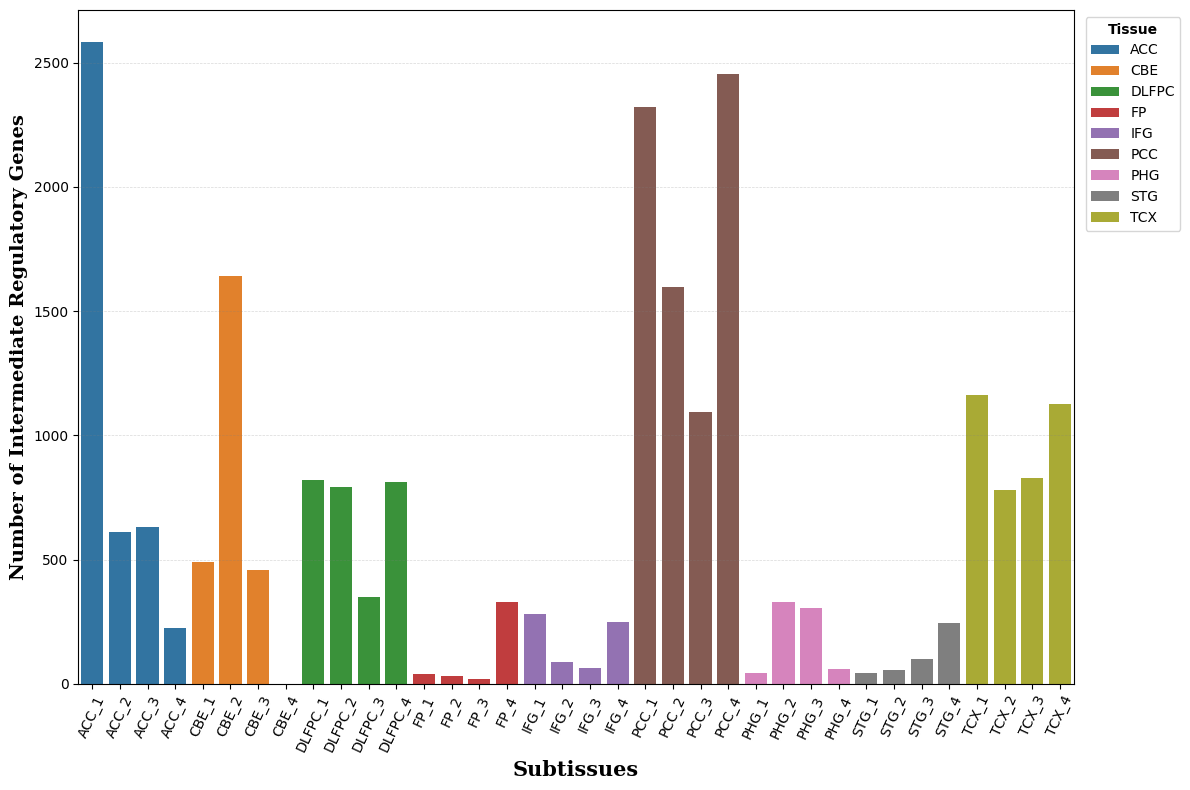

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame

# Extract the tissue and cluster numbers from the 'Cluster' column
df['Tissue_Number'] = df['Cluster'].apply(lambda x: int(x.split('_')[0]))
df['Cluster_Number'] = df['Cluster'].apply(lambda x: int(x.split('_')[1]))

# Tissue name mapping based on your dictionary
tissue_dict = {1: 'ACC', 2: 'CBE', 3: 'DLFPC', 4: 'FP', 5: 'IFG', 6: 'PCC', 7: 'PHG', 8: 'STG', 9: 'TCX'}

# Map the 'Tissue_Number' to tissue names
df['Tissue'] = df['Tissue_Number'].map(tissue_dict)

# Define a custom color palette with distinct colors for each tissue
# We need 9 colors, one for each unique tissue
palette = sns.color_palette("tab10", n_colors=len(tissue_dict))

# Create a new 'Cluster_ID' to uniquely identify each cluster across all tissues
df['Cluster_ID'] = df['Tissue'] + '_' + df['Cluster_Number'].astype(str)

# Create the bar plot using Seaborn
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Cluster_ID', y='Total Unique Intermediates', data=df, hue='Tissue', palette=palette, dodge=False)

# Set the labels with specific font styles
ax.set_xlabel('Subtissues', fontdict={'size': 15, 'weight': 'bold', 'family': 'serif'})
ax.set_ylabel('Number of Intermediate Regulatory Genes', fontdict={'size': 14, 'weight': 'bold', 'family': 'serif'})
# ax.set_title('Subtissue-Specific Gene Expression Insights (ML-Detected Genes)')

# Enable the horizontal grid with opacity
ax.yaxis.grid(True)  # Enable the Y-axis grid lines
ax.grid(True, which='major', axis='y', linestyle='--', linewidth='0.5', color='grey', alpha=0.3)

# Adjust the x-ticks to show cluster IDs
ax.set_xticklabels(df['Cluster_ID'].unique(), rotation=65)


# Display legend for tissue groups and make the title bold
legend = plt.legend(title='Tissue', bbox_to_anchor=(1.005, 1), loc='upper left')
plt.setp(legend.get_title(), fontweight='bold')

# Optionally add custom bold text style
# plt.rcParams["font.weight"] = "bold"

# Show the plot
plt.tight_layout()

plt.savefig("./figures/subtissues_intermediates_count.png", dpi=1200)

plt.show()


Subtissue specific Bottleneck genes

In [ ]:
import pickle
import os

# Load the dictionary from the pickle file
pickle_dir = os.path.expanduser('~/rnaseq_synapse')
with open(f'{pickle_dir}/novel_hub_genes_by_cluster.pkl', 'rb') as file:
    gene_dict = pickle.load(file)
gene_dict 

{'1_1': [('LOC107986669', 1.0, 'betweenness'),
  ('CTSK', 2.0, 'betweenness'),
  ('MEI1', 1.0, 'closeness'),
  ('LOC105371735', 2.0, 'closeness'),
  ('TNFSF13B', 3.0, 'closeness'),
  ('ZNF837', 4.0, 'closeness'),
  ('ZCCHC24', 1.0, 'pagerank'),
  ('SMPX', 2.0, 'pagerank'),
  ('COL19A1', 3.0, 'pagerank'),
  ('KEL', 4.0, 'pagerank'),
  ('TNFSF13B', 5.0, 'pagerank')],
 '1_2': [('TGFA', 1.0, 'betweenness'),
  ('FRMPD4', 2.0, 'betweenness'),
  ('WWTR1', 3.0, 'betweenness'),
  ('WWTR1', 1.0, 'closeness')],
 '1_3': [('PLPP3', 1.0, 'degree'),
  ('ADAMTS1', 1.0, 'betweenness'),
  ('DCDC1', 2.0, 'betweenness'),
  ('CFAP300', 3.0, 'betweenness'),
  ('LENG9', 4.0, 'betweenness'),
  ('CYBA', 5.0, 'betweenness'),
  ('ZYX', 1.0, 'closeness'),
  ('FJX1', 2.0, 'closeness'),
  ('PDE1B', 1.0, 'eigenvector'),
  ('KCNV1', 2.0, 'eigenvector'),
  ('DLX6', 3.0, 'eigenvector'),
  ('XK', 4.0, 'eigenvector'),
  ('DCAF12L2', 5.0, 'eigenvector'),
  ('PLPP3', 1.0, 'pagerank'),
  ('ANO6', 2.0, 'pagerank'),
  ('MIR36

/tmp/ipykernel_20067/3785659827.py:52: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['Cluster_ID'].unique(), rotation=65)


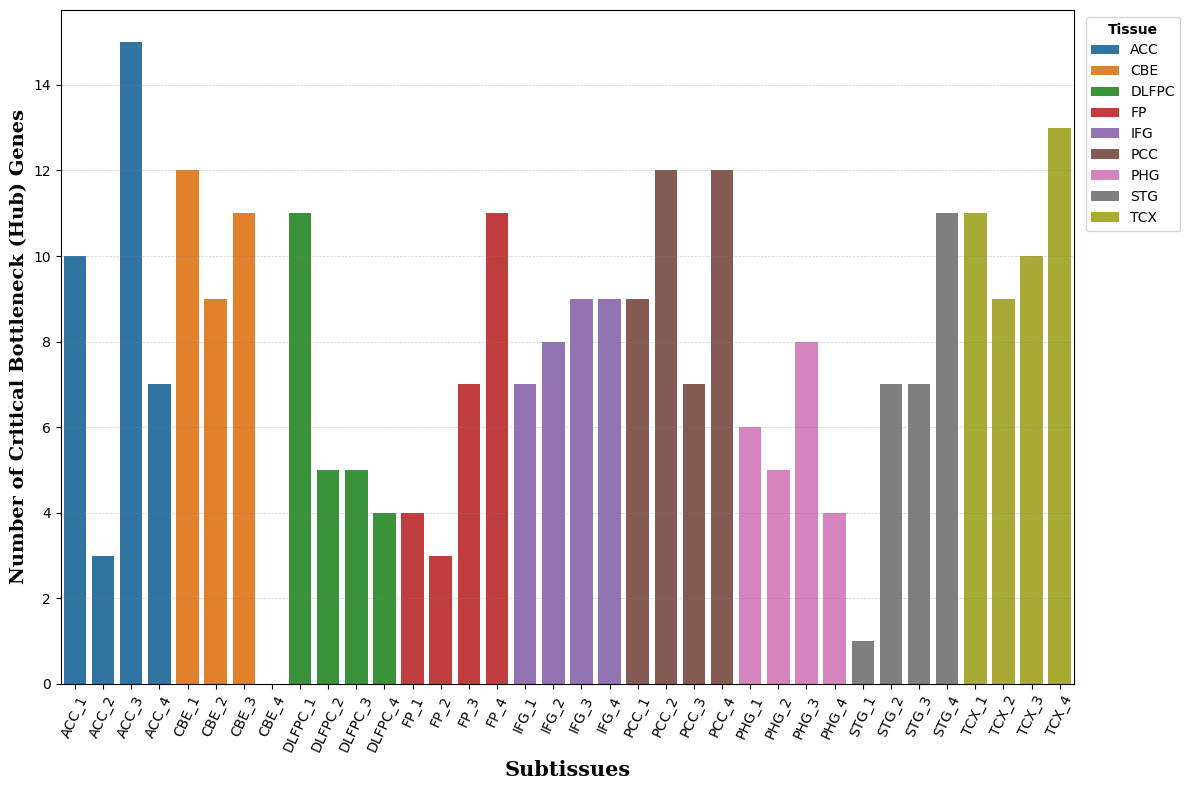

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import os

# Load the dictionary from the pickle file
pickle_dir = os.path.expanduser('~/rnaseq_synapse')
with open(f'{pickle_dir}/novel_hub_genes_by_cluster.pkl', 'rb') as file:
    gene_dict = pickle.load(file)

# Initialize all possible clusters with zero counts
expected_clusters = {
    '1_1': 0, '1_2': 0, '1_3': 0, '1_4': 0,
    '2_1': 0, '2_2': 0, '2_3': 0, '2_4': 0,  # Ensure CBE has a fourth cluster
    '3_1': 0, '3_2': 0, '3_3': 0, '3_4': 0,
    '4_1': 0, '4_2': 0, '4_3': 0, '4_4': 0,
    '5_1': 0, '5_2': 0, '5_3': 0, '5_4': 0,  # Ensure CBE has a fourth cluster
    '6_1': 0, '6_2': 0, '6_3': 0, '6_4': 0,
    '7_1': 0, '7_2': 0, '7_3': 0, '7_4': 0,
    '8_1': 0, '8_2': 0, '8_3': 0, '8_4': 0,  # Ensure CBE has a fourth cluster
    '9_1': 0, '9_2': 0, '9_3': 0, '9_4': 0,
    # Add other clusters similarly
}

# Update with actual counts from the gene_dict
for cluster, gene_list in gene_dict.items():
    expected_clusters[cluster] = len(set([gene[0] for gene in gene_list]))

# Convert to DataFrame
df = pd.DataFrame(list(expected_clusters.items()), columns=['Cluster', 'Novel Gene Count'])

# Extract tissue and cluster numbers
df['Tissue_Number'] = df['Cluster'].apply(lambda x: int(x.split('_')[0]))
df['Cluster_Number'] = df['Cluster'].apply(lambda x: int(x.split('_')[1]))

# Tissue name mapping
tissue_dict = {1: 'ACC', 2: 'CBE', 3: 'DLFPC', 4: 'FP', 5: 'IFG', 6: 'PCC', 7: 'PHG', 8: 'STG', 9: 'TCX'}
df['Tissue'] = df['Tissue_Number'].map(tissue_dict)

# Create a new 'Cluster_ID' to uniquely identify each cluster across all tissues
df['Cluster_ID'] = df['Tissue'] + '_' + df['Cluster_Number'].astype(str)

# Define a custom color palette with distinct colors for each tissue
palette = sns.color_palette("tab10", n_colors=len(tissue_dict))

# Create the bar plot using Seaborn
plt.figure(figsize=(12, 8))
ax = sns.barplot(x='Cluster_ID', y='Novel Gene Count', data=df, hue='Tissue', palette=palette, dodge=False)

# Adjust the x-ticks to show cluster IDs
ax.set_xticklabels(df['Cluster_ID'].unique(), rotation=65)

# Set the labels and title with specific font styles
ax.set_xlabel('Subtissues', fontdict={'size': 15, 'weight': 'bold', 'family': 'serif'})
ax.set_ylabel('Number of Critical Bottleneck (Hub) Genes', fontdict={'size': 14, 'weight': 'bold', 'family': 'serif'})

# Enable the horizontal grid with opacity
ax.yaxis.grid(True)  # Enable the Y-axis grid lines
ax.grid(True, which='major', axis='y', linestyle='--', linewidth='0.5', color='grey', alpha=0.4)

# Optionally remove the legend title and set its font to bold
legend = plt.legend(title='Tissue', bbox_to_anchor=(1.005, 1), loc='upper left')
plt.setp(legend.get_title(), fontweight='bold')

# Show the plot with a clear separation of clusters per tissue
plt.tight_layout()

plt.savefig("./figures/subtissues_bottleneck_genes.png", dpi=1200)
plt.show()


Subtissue specific biomarkers

/tmp/ipykernel_37801/980488832.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df['cluster_label'], rotation=45)


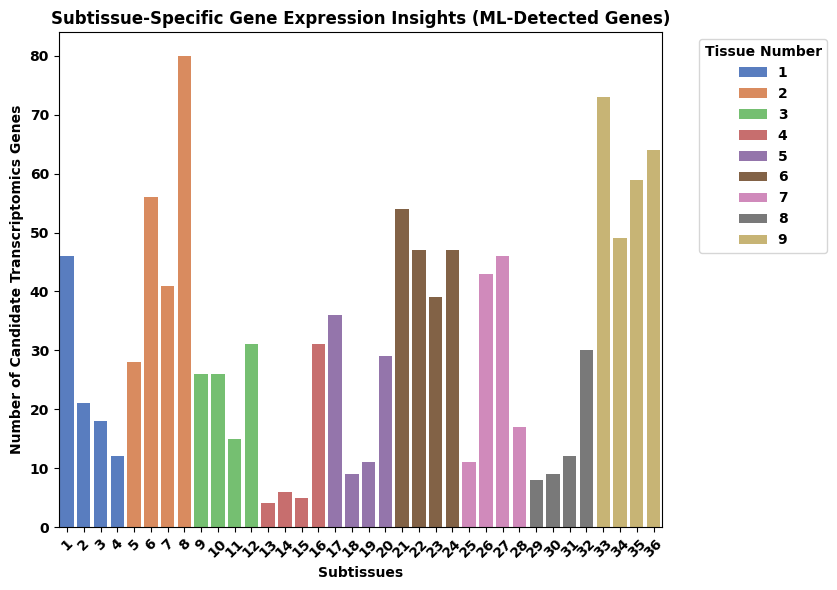

In [ ]:
# For all the tissues

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming your dataframe is named df

# Step 1: Extract the tissue number from the 'Cluster' column
df['Tissue'] = df['Cluster'].apply(lambda x: x.split('_')[0])

# Step 2: Map the 'Cluster' column to numeric labels (1 to N)
df['cluster_label'] = range(1, len(df) + 1)



# Step 3: Define a custom color palette with distinct colors for each tissue
# The number of distinct colors should match the number of unique tissue values
palette = sns.color_palette("muted", len(df['Tissue'].unique()))

# Step 4: Create the bar plot using Seaborn
plt.figure(figsize=(8.5, 6))
ax = sns.barplot(x='cluster_label', y='Common SHAP Genes Count', data=df, hue='Tissue', palette=palette, dodge=False)

# Step 5: Set the labels and title
ax.set_xlabel('Subtissues')
ax.set_ylabel('Number of Candidate Transcriptomics Genes')
ax.set_title('Subtissue-Specific Gene Expression Insights (ML-Detected Genes)')

# Adjust the x-ticks to show subtissue numbering starting from 1
ax.set_xticklabels(df['cluster_label'], rotation=45)

# Display legend for tissue groups
plt.legend(title='Tissue Number', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add this line before plt.tight_layout() to make all text bold
plt.rcParams["font.weight"] = "bold"


# Show the plot
plt.tight_layout()
plt.savefig("./figures/SHAP_biomarkers_subtissues.png", dpi=1200)
plt.show()
